# Notebook 06 — Final velocity dispersion at standard apertures

**Final** σ measurement for the ApJL paper at three literature-standard circular apertures:

| Aperture | Alias | Literature reference |
|---|---|---|
| R < R_e / 8 | σ_c | Jørgensen, Franx & Kjærgaard 1995 — Fundamental Plane / pre-2013 M•–σ |
| R < R_e / 2 |  — | Cappellari+2006 (less Sersic-sensitive than σ_c) |
| **R < R_e** | **σ_e** | **Kormendy & Ho 2013 (ARA&A §6.6); Greene, Strader & Ho 2020 (ARA&A §3.1) — the primary number for the modern M•–σ relation** |

σ_e (R < R_e) is the headline number that feeds directly into the KH13/Greene+20 M•–σ scaling relations. σ_c (R < R_e/8) is reported for comparison with pre-2013 early-type literature that use the JFK95 fiber convention.

### Pipeline

Same wild-bootstrap + posterior-combining method that produced the 190-spaxel integrated σ in notebook 03c / `AGEL_0206_ApJL_Figures/figures.ipynb`, applied to each circular aperture:

1. Extract an integrated spectrum at each aperture from the KCWI cube, using a PSF-aware contamination-weighted average (weights = `1 − contam_frac`, where `contam_frac` is the HST F140W arc mask convolved with the KCWI seeing PSF).
2. Run ppxf at 30 polynomial degrees × 3 SPS libraries (FSPS, EMILES, XSL) at z = 0.67564 (systemic) to obtain the best-fit model at each degree.
3. Run the hybrid wild bootstrap (Rademacher × local-residual scaling, 75-pixel window) at N = 500 per degree, reusing `run_bootstrap_single_degree()` from `scripts/bootstrap_ppxf.py`.
4. Combine posteriors across (SPS × degrees) by concatenation — pool all bootstrap samples from degrees 15–29 × 3 SPS libraries into a single posterior and report 16/50/84 percentiles.
5. Save to `results/final_sigma_Re_apertures.npz` for Figure 2 of the ApJL.

### Runtime

Full N=500: ~30 min per aperture × 3 apertures = ~90 min (single redshift). For a smoke test, set `N_BOOTSTRAP = 10` and `DEGREES = np.arange(10, 22)`; expect ~3 min total.

### Cross-checks

- σ(<R_e/2) should agree with 05x Test 15's R<1.3" EMILES bin (~215–240 km/s per memory).
- Applying the same combining logic to the existing `ppxf_bootstrap_errors_{sps}_z067564.npz` (190-spaxel box) must reproduce ~301 ± 30 km/s — if it doesn't, the combiner is broken before we trust the new-aperture numbers.

In [ ]:
import os
import sys
from time import perf_counter as clock

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from scipy.ndimage import gaussian_filter, map_coordinates
from tqdm import tqdm

from ppxf.ppxf import ppxf

# Import the bootstrap machinery (after the setup_ppxf_inputs_from_spectrum refactor)
sys.path.insert(0, os.path.abspath('..'))
from scripts.bootstrap_ppxf import (
    setup_ppxf_inputs_from_spectrum,
    run_bootstrap_single_degree,
    NOISE_SLICE,
    DEFLECTOR_SLICE,
    C_KMS,
)

plt.rcParams['figure.facecolor'] = 'white'
plt.rc('font', family='serif', size=13)
plt.rc('axes', linewidth=1.3, labelsize=14)
plt.rc('xtick', labelsize=12, direction='in')
plt.rc('ytick', labelsize=12, direction='in')

In [ ]:
# ============================================================
# Configuration — tune these for smoke test vs full run
# ============================================================

# Paths
IFU_FILE = '../Nov17_2025_DESJ0206_RL_combined_icubes_wcs.fits'
HST_CUTOUT = '../../velocity_dispersion_from_IFU/AGEL020613-011417A_F140W_WFC3_cutout_L3.fits'
HST_MASK = '../../velocity_dispersion_from_IFU/AGEL020613-011417A_F140W_WFC3_cutout_L3_mask.fits'
RE_FILE = '../results/Re_measurements.npz'
RESULTS_DIR = '../results'
FIG_DIR = '../results/figures'
os.makedirs(FIG_DIR, exist_ok=True)

# Science config
Z_SYSTEMIC = 0.67564           # from notebook 04 line-fitting
SPS_LIBS = ['fsps', 'emiles', 'xsl']
DEGREES = np.arange(0, 30)     # 30 polynomial degrees, same as notebooks 03/03b
N_BOOTSTRAP = 500              # set to 10 for a smoke test (~3 min), 500 for paper (~90 min)
BOOT_SEED = 42
WINDOW = 75                    # local-residual rolling window (pixels), matches 03

# Combining config (matches 03c / figures.ipynb)
COMBINE_DEG_RANGE = np.arange(15, 30)  # stable range per 03c/figures.ipynb

# Contamination masking
KCWI_SEEING_FWHM = 1.27        # arcsec (from GUIDFWHM header)
HST_PIXSCALE = 0.08            # arcsec/pix (WFC3/IR)
CONTAM_THRESHOLD = 0.15        # 15% — matches 05x

print(f'N_BOOTSTRAP = {N_BOOTSTRAP}')
print(f'DEGREES     = {DEGREES[0]}..{DEGREES[-1]} ({len(DEGREES)} values)')
print(f'SPS_LIBS    = {SPS_LIBS}')
print(f'z_systemic  = {Z_SYSTEMIC}')

## 1. Load IFU cube + HST mask; build PSF-aware contamination map

Same procedure as 05x cells 15, 24, 25 — see `notebooks/05x_sigma_discrepancy_diagnostic.ipynb` for validation plots.

In [ ]:
# Load cube
with fits.open(IFU_FILE) as hdul:
    hdr = hdul[0].header
    cube = np.asarray(hdul[0].data, dtype=float)

# Wavelength array (vacuum, observed) on native cube grid
crval = hdr['CRVAL3']
cdelt = hdr['CD3_3']
npix_w = hdr['NAXIS3']
crpix = hdr.get('CRPIX3', 1.0)
lam_native = crval + cdelt * (np.arange(npix_w) + 1 - crpix)

print(f'Cube: {cube.shape}, lambda: {lam_native[0]:.0f}-{lam_native[-1]:.0f} A')

# Load HST mask + cutout (for WCS)
mask_hst = fits.getdata(HST_MASK).astype(bool)
hdr_cutout = fits.getheader(HST_CUTOUT)
wcs_cutout = WCS(hdr_cutout)
print(f'HST mask: {mask_hst.shape}, {np.sum(mask_hst)} pixels flagged')

In [ ]:
# PSF-aware contamination map (05x cells 24-25)
psf_sigma_hst_pix = (KCWI_SEEING_FWHM / HST_PIXSCALE) / 2.355
mask_convolved = gaussian_filter(mask_hst.astype(float), sigma=psf_sigma_hst_pix)

# Reproject onto IFU spaxel grid
wcs_ifu_2d = WCS(hdr, naxis=2)
ny, nx = cube.shape[1], cube.shape[2]
yy, xx = np.mgrid[0:ny, 0:nx]
ra_ifu, dec_ifu = wcs_ifu_2d.pixel_to_world_values(xx.ravel(), yy.ravel())
x_hst, y_hst = wcs_cutout.world_to_pixel_values(ra_ifu, dec_ifu)
spaxel_contam = map_coordinates(
    mask_convolved, [y_hst, x_hst], order=1, mode='constant', cval=0.0
).reshape(ny, nx)
spaxel_masked = spaxel_contam > CONTAM_THRESHOLD

print(f'IFU spaxels above {100*CONTAM_THRESHOLD:.0f}% contamination: '
      f'{np.sum(spaxel_masked)} / {ny*nx}')

# Deflector center: IFU white-light peak (same as 05x cell 20)
wl = np.sum(cube, axis=0)
wl_smooth = gaussian_filter(wl, sigma=2)
cy, cx = np.unravel_index(np.argmax(wl_smooth), wl_smooth.shape)
print(f'White-light center: spaxel ({cx}, {cy})')

# Per-spaxel angular distance from center in arcsec
ra_c, dec_c = wcs_ifu_2d.pixel_to_world_values(cx, cy)
dra = (ra_ifu.reshape(ny, nx) - ra_c) * np.cos(np.radians(dec_c)) * 3600
ddec = (dec_ifu.reshape(ny, nx) - dec_c) * 3600
r_spax = np.sqrt(dra**2 + ddec**2)

# Quick viz of the contamination map + center
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(wl, origin='lower', cmap='viridis',
               vmin=np.percentile(wl, 5), vmax=np.percentile(wl, 99))
axes[0].plot(cx, cy, 'r+', ms=12, mew=2)
axes[0].set_title('IFU white-light + center')
axes[0].set_xlim(30, 75); axes[0].set_ylim(30, 75)

im = axes[1].imshow(spaxel_contam, origin='lower', cmap='hot', vmin=0, vmax=0.3)
axes[1].set_title(f'Contamination fraction (threshold={CONTAM_THRESHOLD})')
axes[1].set_xlim(30, 75); axes[1].set_ylim(30, 75)
plt.colorbar(im, ax=axes[1])

axes[2].imshow(r_spax, origin='lower', cmap='plasma', vmax=3.0)
axes[2].set_title('Radial distance (arcsec)')
axes[2].set_xlim(30, 75); axes[2].set_ylim(30, 75)
plt.tight_layout()
plt.show()

## 2. Define the three apertures

R_e is loaded from `results/Re_measurements.npz`. We use the **HST F140W (proper mask)** value:

- F140W is the **brightest band** in which we see the deflector — the highest-S/N optical-band image.
- WFC3/IR F140W samples rest-frame ~830 nm at z=0.676 — close to the rest-frame V band that Kormendy & Ho 2013 use to measure half-light radii for the M•–σ relation.
- The 'proper mask' variant excludes the lensed arc rigorously via `photutils.ApertureStats(mask=...)` (in contrast to the 'zeroed' variant which biases annular means low).

**Caveat — bulge vs. total Re.** KH13 strictly want the *bulge* effective radius from a bulge+disk decomposition. AGEL0206 is a spiral with a clear disk component; we have no B+D decomp, so this is the *total*-galaxy Re. For a spiral, the bulge Re would be smaller, which would push the integration toward more centrally-concentrated (and BH-dominated) spaxels and likely *raise* σ_e. Using total-galaxy Re therefore biases σ_e *low* relative to the strict KH13 definition — a conservative choice for an ApJL claiming AGEL0206 sits below the M•–σ relation.


In [ ]:
re_data = np.load(RE_FILE, allow_pickle=True)
labels = re_data['labels']
re_values = re_data['Re_values']
kpc_per_arcsec = float(re_data['kpc_per_arcsec'])

# Pick the IFU white-light (masked >15%) entry — self-consistent with our pipeline
re_idx = np.where(labels == 'HST F140W (proper mask)')[0][0]
R_e = float(re_values[re_idx])
print(f'R_e = {R_e:.3f}" = {R_e * kpc_per_arcsec:.2f} kpc  (source: {labels[re_idx]})  *** F140W proper-mask ***')

# Aperture definitions
APERTURES = {
    'Re8':  R_e / 8.0,
    'Re2':  R_e / 2.0,
    'Re':   R_e,
}
APERTURE_LABELS = {
    'Re8': r'$R < R_e/8$ (JFK95 $\sigma_c$)',
    'Re2': r'$R < R_e/2$',
    'Re':  r'$R < R_e$ ($\sigma_e$; KH13, Greene+20)',
}

print()
print(f'{"aperture":<6} {"R_arcsec":>10} {"R_kpc":>10} {"N_spax":>8} {"N_contam_free":>14}')
for tag, r_max in APERTURES.items():
    mask_r = r_spax <= r_max
    n_all = int(mask_r.sum())
    n_clean = int((mask_r & ~spaxel_masked).sum())
    print(f'{tag:<6} {r_max:8.3f} {r_max*kpc_per_arcsec:10.2f} {n_all:8d} {n_clean:14d}')

## 2b. Verify R_e against masked IFU and HST (F140W, F200LP)

Re-run the full `scripts/measure_Re.py` pipeline in-notebook so the R_e we use for the apertures is *provably* the same number `results/Re_measurements.npz` was computed with, and so we can see the full multi-source comparison.

Three data sources × multiple masking strategies:

- **IFU white-light** (KCWI, 0.30"/spaxel, 15% PSF-convolved contamination mask used for the paper)
- **HST F140W** (WFC3/IR, 0.08"/pix) — no mask / arc-zeroed / proper-mask (ApertureStats) variants
- **HST F200LP** (WFC3/UVIS, 0.08"/pix) — same three masking variants

Each measurement produces a radial light profile `I(r)`, a curve of growth `∫ I(r)·2πr dr`, and R_e at the 50% cumulative-flux radius. Stacking all sources/strategies side by side shows how much R_e depends on *what you measure* and *how you deblend the arc*.

In [ ]:
from scripts.measure_Re import run_all as _run_all_Re, KPC_PER_ARCSEC as _KPC

# Re-run all R_e measurements in this session
results_fresh = _run_all_Re(verbose=False)

# Load the saved measurements for comparison
re_saved = np.load(RE_FILE, allow_pickle=True)
saved_labels = list(re_saved['labels'])
saved_Re = re_saved['Re_values']
fresh_by_label = {r['label']: r['Re'] for r in results_fresh}

print(f'{"Label":<45} {"saved Re":>10} {"fresh Re":>10} {"diff":>8} {"kpc":>7}')
print('-' * 85)
for lbl, r_saved in zip(saved_labels, saved_Re):
    r_fresh = fresh_by_label.get(lbl, np.nan)
    diff = r_fresh - r_saved
    mark = '  OK' if abs(diff) < 1e-3 else '  **MISMATCH**'
    print(f'{lbl:<45} {r_saved:10.4f} {r_fresh:10.4f} {diff:+8.4f} {r_fresh*_KPC:7.2f}{mark}')

# Highlight the value used for the apertures above
print()
print(f'Aperture-defining Re: {R_e:.3f}" = {R_e*kpc_per_arcsec:.2f} kpc  '
      f'(source: "{labels[re_idx]}")')
if abs(R_e - fresh_by_label[str(labels[re_idx])]) < 1e-3:
    print('   -> fresh in-notebook computation reproduces the saved value exactly.')

In [ ]:
# Three-panel comparison: radial profiles, curves of growth, Re bar chart
# (inline version of scripts.measure_Re.plot_comparison)

source_colors = {'IFU': 'C0', 'HST F140W': 'C1', 'HST F200LP': 'C2'}

def _style(label):
    if 'unmasked' in label or label.endswith('(none)'):
        return '-', 0.4, '..'
    if 'zeroed' in label:
        return '--', 0.6, '//'
    if 'proper' in label:
        return '-', 1.0, ''
    # masked-IFU variants (masked >N%)
    return ':', 0.8, ''

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: radial profiles, normalized to the innermost sample of each profile
for r in results_fresh:
    ls, alpha, _ = _style(r['label'])
    c = source_colors.get(r['method'], 'gray')
    rp, Ip = r['r_profile'], r['I_profile']
    if len(Ip) == 0 or Ip[0] <= 0:
        continue
    short = r['label'].replace('HST ', '').replace('IFU white-light ', 'IFU ')
    axes[0].plot(rp, Ip / Ip[0], color=c, ls=ls, alpha=alpha, lw=1.5, label=short)
    axes[0].axvline(r['Re'], color=c, ls=ls, alpha=alpha * 0.5, lw=0.7)

axes[0].set_xlabel('R (arcsec)'); axes[0].set_ylabel('Normalized intensity')
axes[0].set_yscale('log'); axes[0].set_ylim(1e-3, 1.5); axes[0].set_xlim(0, 6)
axes[0].set_title('Radial light profiles')
axes[0].legend(fontsize=7, loc='upper right', ncol=1)
axes[0].grid(alpha=0.3)

# Panel 2: curves of growth
for r in results_fresh:
    ls, alpha, _ = _style(r['label'])
    c = source_colors.get(r['method'], 'gray')
    cog, total = r['cog'], r['total']
    if total <= 0:
        continue
    r_cog = np.concatenate([[0], r['r_profile']])
    axes[1].plot(r_cog, cog / total, color=c, ls=ls, alpha=alpha, lw=1.5)
    axes[1].axvline(r['Re'], color=c, ls=ls, alpha=alpha * 0.5, lw=0.7)

axes[1].axhline(0.5, color='gray', ls='--', lw=1, alpha=0.5)
axes[1].set_xlabel('R (arcsec)'); axes[1].set_ylabel('Cumulative flux fraction')
axes[1].set_title('Curve of growth')
axes[1].set_xlim(0, 6); axes[1].grid(alpha=0.3)

# Panel 3: Re bar chart, highlighting the aperture-defining value
labels_short = [r['label'].replace('HST ', '').replace('IFU white-light ', 'IFU ') for r in results_fresh]
Re_vals = [r['Re'] for r in results_fresh]
bar_colors = [source_colors.get(r['method'], 'gray') for r in results_fresh]
hatches = [_style(r['label'])[2] for r in results_fresh]
chosen_label = str(labels[re_idx]).replace('HST ', '').replace('IFU white-light ', 'IFU ')

y_pos = np.arange(len(labels_short))
bars = axes[2].barh(y_pos, Re_vals, color=bar_colors, alpha=0.75,
                     edgecolor='black', lw=0.6)
for bar, h in zip(bars, hatches):
    bar.set_hatch(h)
# Thick outline on the chosen bar
for bar, lbl in zip(bars, labels_short):
    if lbl == chosen_label:
        bar.set_edgecolor('red')
        bar.set_linewidth(2.2)

# Reference lines for Re, Re/2, Re/8 using the chosen value
for frac, lbl in [(1.0, 'Re'), (0.5, 'Re/2'), (1/8, 'Re/8')]:
    axes[2].axvline(R_e * frac, color='red', ls=':', lw=1.0, alpha=0.55)
    axes[2].text(R_e * frac, -0.7, lbl, color='red', ha='center', fontsize=9)

axes[2].set_yticks(y_pos)
axes[2].set_yticklabels(labels_short, fontsize=8)
axes[2].set_xlabel(r'$R_e$ (arcsec)')
axes[2].set_title(r'$R_e$ across sources (red = aperture-defining value)')
axes[2].grid(alpha=0.3, axis='x')

# kpc axis on top
ax2 = axes[2].twiny()
xlim = axes[2].get_xlim()
ax2.set_xlim(xlim[0] * kpc_per_arcsec, xlim[1] * kpc_per_arcsec)
ax2.set_xlabel(r'$R_e$ (kpc)')

fig.suptitle(f'R_e verification — 3 sources × masking strategies.  '
             f'Aperture value: {R_e:.3f}" = {R_e*kpc_per_arcsec:.2f} kpc', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'Re_verification.png'), dpi=180, bbox_inches='tight')
plt.show()

# Quantitative summary of source-to-source scatter
IFU_re = [r['Re'] for r in results_fresh if r['method'] == 'IFU']
F140_re = [r['Re'] for r in results_fresh if r['method'] == 'HST F140W']
F200_re = [r['Re'] for r in results_fresh if r['method'] == 'HST F200LP']
print()
print(f'R_e spread by source (arcsec):')
print(f'  IFU (4 masking thresholds): {min(IFU_re):.2f} - {max(IFU_re):.2f}  (median {np.median(IFU_re):.2f})')
print(f'  HST F140W (3 strategies):   {min(F140_re):.2f} - {max(F140_re):.2f}  (median {np.median(F140_re):.2f})')
print(f'  HST F200LP (3 strategies):  {min(F200_re):.2f} - {max(F200_re):.2f}  (median {np.median(F200_re):.2f})')
print(f'\nAll 10 values scatter: min {min(Re_vals):.2f}", max {max(Re_vals):.2f}", median {np.median(Re_vals):.2f}"')

## 3. Extract integrated spectra at each aperture

Contamination-weighted spatial average (weights = `1 − contam_frac`, clipped to [0.01, 1]), matching 05x cell 45. Noise is from the sky/off-galaxy region defined in `bootstrap_ppxf.NOISE_SLICE` (`cube[:, 28:40, 45:70]`).

In [ ]:
# Noise spectrum on native wavelength grid (same for all apertures)
noise_native = np.std(cube[:, NOISE_SLICE[0], NOISE_SLICE[1]], axis=(1, 2))

aperture_spectra = {}  # tag -> dict(flux, noise, n_spax, r_arcsec, r_kpc)
for tag, r_max in APERTURES.items():
    mask_r = r_spax <= r_max
    if mask_r.sum() < 1:
        raise RuntimeError(f'Aperture {tag} has 0 spaxels — check center')
    if mask_r.sum() == 1:
        print(f'WARNING: Aperture {tag} contains only the central spaxel '
              f'(R_max={r_max:.3f}\" < 1 spaxel radius). Single-spaxel ppxf will be noisy.')
    weights = np.clip(1.0 - spaxel_contam[mask_r], 0.01, 1.0)
    flux = np.average(cube[:, mask_r], axis=1, weights=weights)
    aperture_spectra[tag] = {
        'flux': flux,
        'noise': noise_native.copy(),
        'n_spax': int(mask_r.sum()),
        'r_arcsec': r_max,
        'r_kpc': r_max * kpc_per_arcsec,
        'mean_contam': float(weights.mean()),
    }
    print(f'{tag}: N_spax={mask_r.sum()}, mean weight={weights.mean():.3f}')

# Quick visual of the three extracted spectra
fig, ax = plt.subplots(figsize=(12, 4))
for tag, spec in aperture_spectra.items():
    norm = spec['flux'] / np.median(spec['flux'])
    ax.plot(lam_native, norm + {'Re8': 2.0, 'Re2': 1.0, 'Re': 0.0}[tag],
            lw=0.7, label=f'{tag} (N={spec["n_spax"]})')
ax.set_xlabel('Wavelength (A, obs)')
ax.set_ylabel('Flux (normalized, stacked)')
ax.legend()
ax.set_title('Aperture spectra (normalized, offset for clarity)')
ax.set_xlim(6400, 7600)
plt.tight_layout()
plt.show()

## 3b. Visualize the three apertures on the white-light image and PowerBin map

Three panels:

1. **IFU white-light + apertures** — overlay R_e/8, R_e/2, R_e circles on the image; contamination-masked spaxels highlighted in red. Confirms the apertures are centered on the deflector and shows how much of each aperture is affected by the lensed arc.
2. **Contamination fraction + apertures** — the smooth PSF-convolved arc-contamination map (same one that feeds the weights in the integrated spectra above). Lets us read off the mean contamination level inside each aperture.
3. **PowerBin map + apertures** — the 19-bin PowerBin partition from Test 19 in `05x_sigma_discrepancy_diagnostic.ipynb` (loaded from `results/test19_powerbin_results.npz`). Shows which PowerBin bins contribute to each aperture — e.g. how many bins sit inside R_e/8 (probably 1) vs inside R_e (many). Useful for interpreting the σ radial rise: apertures that straddle PowerBin boundaries pick up bins of very different σ.

In [ ]:
from astropy.wcs.utils import proj_plane_pixel_scales
from matplotlib.patches import Circle

# Pixel scale from WCS (arcsec/spaxel)
pix_scale = float(np.abs(proj_plane_pixel_scales(wcs_ifu_2d)[0])) * 3600.0
print(f'IFU pixel scale: {pix_scale:.4f} arcsec/spaxel')

# Load PowerBin partition produced by Test 19 of 05x
pb_path = os.path.join(RESULTS_DIR, 'test19_powerbin_results.npz')
pb_data = np.load(pb_path, allow_pickle=True)
pb_map = pb_data['pb_map']           # shape (40, 40) on the Test-19 wide region
pb_y_slice = slice(35, 75)           # hardcoded in scripts/run_powerbin_test19.py
pb_x_slice = slice(30, 70)
n_pbins = int(pb_data['n_pbins'])
print(f'Loaded {n_pbins} PowerBin bins from {pb_path}')

# Re-project PowerBin map onto the full 100x100 IFU grid (-1 outside the wide region)
pb_map_full = np.full((ny, nx), -1, dtype=int)
pb_map_full[pb_y_slice, pb_x_slice] = pb_map

# For each aperture, count how many PowerBin bins have any overlap with it
print()
print(f'{"aperture":<6} {"R (arcsec)":>10} {"R (spax)":>10} {"N_bins_overlap":>16}')
bins_touching = {}
for tag, r_max in APERTURES.items():
    mask_r = r_spax <= r_max
    bins_in = np.unique(pb_map_full[mask_r])
    bins_in = bins_in[bins_in >= 0]
    bins_touching[tag] = bins_in
    print(f'{tag:<6} {r_max:10.3f} {r_max/pix_scale:10.2f} {len(bins_in):16d}')

# Zoom window around the deflector center
delta = 18
y1, y2 = max(0, cy - delta), min(ny, cy + delta)
x1, x2 = max(0, cx - delta), min(nx, cx + delta)
extent = [x1 - 0.5, x2 - 0.5, y1 - 0.5, y2 - 0.5]

aperture_colors = {'Re8': '#ffff55', 'Re2': '#ff88ff', 'Re': '#55ddff'}
aperture_lw = {'Re8': 2.2, 'Re2': 2.0, 'Re': 1.8}

def overlay_apertures(ax, center=(cx, cy)):
    for tag, r_max in APERTURES.items():
        r_pix = r_max / pix_scale
        ax.add_patch(Circle(center, r_pix, fill=False,
                            edgecolor=aperture_colors[tag],
                            lw=aperture_lw[tag],
                            label=APERTURE_LABELS[tag]))
    ax.plot(*center, '+', color='white', mew=2, ms=12)

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# --- Panel 1: white-light + apertures + contamination-masked spaxels ---
ax = axes[0]
ax.imshow(wl, origin='lower', cmap='viridis', extent=[-0.5, nx-0.5, -0.5, ny-0.5],
          vmin=np.percentile(wl, 5), vmax=np.percentile(wl, 99))
ax.imshow(np.where(spaxel_masked, 1, np.nan), origin='lower', cmap='Reds',
          alpha=0.55, extent=[-0.5, nx-0.5, -0.5, ny-0.5])
overlay_apertures(ax)
ax.set_xlim(x1, x2); ax.set_ylim(y1, y2)
ax.set_title('IFU white-light + apertures\n(red = contamination-masked spaxels)')
ax.set_xlabel('x (spaxel)'); ax.set_ylabel('y (spaxel)')

# --- Panel 2: contamination fraction + apertures ---
ax = axes[1]
im = ax.imshow(spaxel_contam, origin='lower', cmap='hot', vmin=0, vmax=0.3,
               extent=[-0.5, nx-0.5, -0.5, ny-0.5])
overlay_apertures(ax)
ax.set_xlim(x1, x2); ax.set_ylim(y1, y2)
ax.set_title(f'Arc contamination fraction\n(PSF-convolved HST mask)')
ax.set_xlabel('x (spaxel)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='contam')

# --- Panel 3: PowerBin map + apertures ---
ax = axes[2]
ax.imshow(wl, origin='lower', cmap='gray',
          extent=[-0.5, nx-0.5, -0.5, ny-0.5],
          vmin=np.percentile(wl, 5), vmax=np.percentile(wl, 99),
          alpha=0.45)
# PowerBin bins with discrete colormap; -1 (outside region) shown as NaN
pb_show = np.where(pb_map_full >= 0, pb_map_full.astype(float), np.nan)
ax.imshow(pb_show, origin='lower', cmap='tab20', alpha=0.75,
          extent=[-0.5, nx-0.5, -0.5, ny-0.5], interpolation='nearest')
overlay_apertures(ax)
ax.set_xlim(x1, x2); ax.set_ylim(y1, y2)
ax.set_title(f'PowerBin partition ({n_pbins} bins, S/N=12)\n(overlay on white-light)')
ax.set_xlabel('x (spaxel)')

# Shared legend (from panel 1) at the bottom
legend_handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(legend_handles, legend_labels, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=11)

fig.suptitle('Test 21-style aperture visualization — Re/8, Re/2, Re relative to '
             'white light, contamination mask, and PowerBin', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'apertures_on_whitelight_and_powerbin.png'),
            dpi=180, bbox_inches='tight')
plt.show()

## 4. Original ppxf fits at every (aperture × SPS × degree)

The bootstrap step needs a best-fit model at each degree to compute residuals. Here we produce the `best_fit` arrays analogous to what `ppxf_integrated_spectrum_results_*.npz` stores for the 190-spaxel box.

In [ ]:
def fit_all_degrees(ppxf_inputs, degrees):
    """Run ppxf at each degree, return arrays of best_fit, sigma, V, chi2, formal_errors."""
    n_pix = len(ppxf_inputs['galaxy'])
    n_deg = len(degrees)
    best_fit = np.zeros((n_deg, n_pix))
    vel_dis = np.zeros(n_deg)
    mean_vel = np.zeros(n_deg)
    fit_chi2 = np.zeros(n_deg)
    error_vdis = np.zeros(n_deg)
    error_mean_vel = np.zeros(n_deg)
    for i, deg in enumerate(degrees):
        pp = ppxf(
            ppxf_inputs['sps'].templates,
            ppxf_inputs['galaxy'], ppxf_inputs['noise'],
            ppxf_inputs['velscale'], ppxf_inputs['start'],
            goodpixels=ppxf_inputs['goodpixels'],
            plot=False, moments=2, trig=False, degree=int(deg), mdegree=0,
            lam=ppxf_inputs['lam_gal_rest'], lam_temp=ppxf_inputs['lam_temp'],
            quiet=True,
        )
        best_fit[i] = pp.bestfit
        mean_vel[i] = pp.sol[0]
        vel_dis[i] = pp.sol[1]
        fit_chi2[i] = pp.chi2
        error_mean_vel[i] = pp.error[0] * np.sqrt(pp.chi2)
        error_vdis[i] = pp.error[1] * np.sqrt(pp.chi2)
    return {
        'best_fit': best_fit,
        'vel_dis': vel_dis,
        'mean_vel': mean_vel,
        'fit_chi2': fit_chi2,
        'error_vdis': error_vdis,
        'error_mean_vel': error_mean_vel,
    }

In [ ]:
# Loop: (aperture, sps) -> ppxf_inputs + original fits
setups = {}  # (tag, sps) -> ppxf_inputs
originals = {}  # (tag, sps) -> fit dict

for tag, spec in aperture_spectra.items():
    for sps in SPS_LIBS:
        print(f'--- Setting up {tag} / {sps} ---')
        inputs = setup_ppxf_inputs_from_spectrum(
            spec['flux'], spec['noise'], hdr,
            sps_name=sps, z=Z_SYSTEMIC, verbose=False,
        )
        setups[(tag, sps)] = inputs
        t0 = clock()
        orig = fit_all_degrees(inputs, DEGREES)
        t1 = clock()
        originals[(tag, sps)] = orig
        sig = orig['vel_dis']
        print(f'    {len(DEGREES)} fits in {t1-t0:.1f}s  '
              f'sigma range {sig.min():.0f}-{sig.max():.0f}  '
              f'chi2 {orig["fit_chi2"].min():.1f}-{orig["fit_chi2"].max():.1f}')

## 5. Wild bootstrap at every (aperture × SPS × degree)

This is the expensive step. ~3 min per (aperture × SPS) at N=10; ~30 min per (aperture × SPS) at N=500. Uses `run_bootstrap_single_degree` from `scripts/bootstrap_ppxf.py` — same machinery as 03/03b — so the output `.npz` files are directly compatible with 03c's combining logic.

In [ ]:
def bootstrap_all_degrees(ppxf_inputs, best_fits, degrees, n_bootstrap, window, seed):
    """Loop run_bootstrap_single_degree over degrees; build the same schema that
    bootstrap_ppxf.run_bootstrap() saves (so 03c's combining code works on it)."""
    n_deg = len(degrees)
    V_b = np.full((n_deg, n_bootstrap), np.nan)
    sig_b = np.full((n_deg, n_bootstrap), np.nan)
    chi_b = np.full((n_deg, n_bootstrap), np.nan)
    z_b = np.full((n_deg, n_bootstrap), np.nan)
    n_failed = np.zeros(n_deg, dtype=int)
    for j, deg in enumerate(tqdm(degrees, desc='  degrees', leave=False)):
        r = run_bootstrap_single_degree(
            ppxf_inputs, degree=int(deg), best_fit_spectrum=best_fits[j],
            n_bootstrap=n_bootstrap, window=window, seed=seed + j,
        )
        V_b[j] = r['V_samples']
        sig_b[j] = r['sigma_samples']
        chi_b[j] = r['chi2_samples']
        z_b[j] = r['z_samples']
        n_failed[j] = r['n_failed']
    return V_b, sig_b, chi_b, z_b, n_failed


boot_results = {}  # (tag, sps) -> dict matching ppxf_bootstrap_errors_*.npz schema
t_total0 = clock()
for tag in APERTURES:
    for sps in SPS_LIBS:
        print(f'=== Bootstrap: {tag} / {sps} (N={N_BOOTSTRAP}, deg={DEGREES[0]}..{DEGREES[-1]}) ===')
        t0 = clock()
        V_b, sig_b, chi_b, z_b, n_fail = bootstrap_all_degrees(
            setups[(tag, sps)], originals[(tag, sps)]['best_fit'],
            DEGREES, N_BOOTSTRAP, WINDOW, BOOT_SEED,
        )
        t1 = clock()
        # Summary percentiles
        sig_p16 = np.nanpercentile(sig_b, 16, axis=1)
        sig_p50 = np.nanpercentile(sig_b, 50, axis=1)
        sig_p84 = np.nanpercentile(sig_b, 84, axis=1)
        V_p16 = np.nanpercentile(V_b, 16, axis=1)
        V_p50 = np.nanpercentile(V_b, 50, axis=1)
        V_p84 = np.nanpercentile(V_b, 84, axis=1)
        z_p16 = np.nanpercentile(z_b, 16, axis=1)
        z_p50 = np.nanpercentile(z_b, 50, axis=1)
        z_p84 = np.nanpercentile(z_b, 84, axis=1)
        out = {
            'V_bootstrap': V_b, 'sigma_bootstrap': sig_b,
            'chi2_bootstrap': chi_b, 'z_bootstrap': z_b,
            'sigma_boot_err_lo': sig_p50 - sig_p16,
            'sigma_boot_err_hi': sig_p84 - sig_p50,
            'sigma_p16': sig_p16, 'sigma_p50': sig_p50, 'sigma_p84': sig_p84,
            'V_boot_err_lo': V_p50 - V_p16,
            'V_boot_err_hi': V_p84 - V_p50,
            'V_p16': V_p16, 'V_p50': V_p50, 'V_p84': V_p84,
            'z_p16': z_p16, 'z_p50': z_p50, 'z_p84': z_p84,
            'V_original': originals[(tag, sps)]['mean_vel'],
            'sigma_original': originals[(tag, sps)]['vel_dis'],
            'chi2_original': originals[(tag, sps)]['fit_chi2'],
            'degrees': np.asarray(DEGREES),
            'sps_name': sps, 'n_bootstrap': N_BOOTSTRAP,
            'n_failed': n_fail,
            'window': WINDOW, 'seed': BOOT_SEED,
            'z_input': Z_SYSTEMIC,
            'aperture_tag': tag,
            'aperture_arcsec': APERTURES[tag],
        }
        boot_results[(tag, sps)] = out
        # Save per-aperture .npz (same schema as bootstrap_ppxf.run_bootstrap output)
        out_path = os.path.join(
            RESULTS_DIR, f'ppxf_bootstrap_errors_R_le_{tag}_{sps}_z067564.npz'
        )
        np.savez(out_path, **out)
        print(f'    done in {t1-t0:.1f}s  [{out_path}]')

print(f'\n*** Total bootstrap time: {(clock()-t_total0)/60:.1f} min ***')

## 6. Diagnostic: σ vs polynomial degree at each aperture

For each aperture, plot σ(degree) for each SPS library with the N=500 bootstrap 68% band. The stable degree range (where σ plateaus) is the one we combine over. 03c identified degrees 15–29 as the stable range for the 190-spaxel integrated spectrum; each aperture needs its own check.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
colors = {'fsps': 'C0', 'emiles': 'C1', 'xsl': 'C2'}

for ax, (tag, label) in zip(axes, APERTURE_LABELS.items()):
    for sps in SPS_LIBS:
        b = boot_results[(tag, sps)]
        ax.fill_between(b['degrees'], b['sigma_p16'], b['sigma_p84'],
                        alpha=0.15, color=colors[sps])
        ax.plot(b['degrees'], b['sigma_original'], '-o', color=colors[sps],
                markersize=4, label=sps)
    ax.axvspan(COMBINE_DEG_RANGE[0], COMBINE_DEG_RANGE[-1],
               color='gray', alpha=0.1, label='combine range')
    ax.set_xlabel('Additive polynomial degree')
    ax.set_ylabel(r'$\sigma$ (km/s)')
    ax.set_title(label)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'sigma_vs_degree_per_aperture.png'),
            dpi=200, bbox_inches='tight')
plt.show()

## 7. Combine posteriors across (SPS × degrees) at each aperture

Following `figures.ipynb` cell 15: concatenate the full `sigma_bootstrap[deg_idx]` arrays across 3 SPS libraries × N degrees into a single pooled posterior, then report 16/50/84 percentiles. This is the method that produced the ApJL integrated σ number — applied here per aperture.

In [ ]:
def combine_posteriors(boot_by_sps, deg_range):
    """Concatenate sigma_bootstrap across SPS libs × degrees in deg_range.
    Returns (pooled_samples, p16, p50, p84)."""
    all_samples = []
    for sps, b in boot_by_sps.items():
        degs = b['degrees']
        mask = np.isin(degs, deg_range)
        # b['sigma_bootstrap'] shape = (n_deg, n_boot); take the rows in deg_range
        samples = b['sigma_bootstrap'][mask].ravel()
        samples = samples[np.isfinite(samples)]
        all_samples.append(samples)
    pooled = np.concatenate(all_samples)
    p16, p50, p84 = np.percentile(pooled, [16, 50, 84])
    return pooled, p16, p50, p84


print(f'Combining degree range: {COMBINE_DEG_RANGE[0]}..{COMBINE_DEG_RANGE[-1]}  ({len(COMBINE_DEG_RANGE)} degrees)')
print(f'Per aperture: {len(SPS_LIBS)} SPS libs x {len(COMBINE_DEG_RANGE)} degrees x {N_BOOTSTRAP} bootstraps '
      f'= {len(SPS_LIBS)*len(COMBINE_DEG_RANGE)*N_BOOTSTRAP} pooled samples expected')
print()

combined = {}  # tag -> dict(samples, p16, p50, p84)
for tag in APERTURES:
    boot_by_sps = {sps: boot_results[(tag, sps)] for sps in SPS_LIBS}
    pooled, p16, p50, p84 = combine_posteriors(boot_by_sps, COMBINE_DEG_RANGE)
    combined[tag] = {'samples': pooled, 'p16': p16, 'p50': p50, 'p84': p84}
    print(f'{APERTURE_LABELS[tag]:55s}  '
          f'sigma = {p50:.1f} (-{p50-p16:.1f}, +{p84-p50:.1f}) km/s  '
          f'[N_samples={len(pooled)}]')

In [ ]:
# Pooled-posterior histograms side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
hist_colors = {'Re8': '#7a4fa0', 'Re2': '#c86a3e', 'Re': '#2a8a5e'}
for ax, tag in zip(axes, APERTURES):
    c = combined[tag]
    ax.hist(c['samples'], bins=80, color=hist_colors[tag], alpha=0.55,
            edgecolor='black', lw=0.3, density=True)
    ax.axvline(c['p50'], color='black', lw=1.5)
    for q, ls in [(c['p16'], '--'), (c['p84'], '--')]:
        ax.axvline(q, color='black', lw=1.0, ls=ls)
    ax.set_xlabel(r'$\sigma$ (km/s)')
    ax.set_title(APERTURE_LABELS[tag] +
                 f'\n$\\sigma = {c["p50"]:.0f}^{{+{c["p84"]-c["p50"]:.0f}}}_{{-{c["p50"]-c["p16"]:.0f}}}$ km/s',
                 fontsize=11)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Density')

plt.suptitle('Pooled posterior σ (3 SPS libs × degrees '
             f'{COMBINE_DEG_RANGE[0]}-{COMBINE_DEG_RANGE[-1]} × N={N_BOOTSTRAP})',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'sigma_combined_posterior_per_aperture.png'),
            dpi=200, bbox_inches='tight')
plt.show()

## 8. Save final results

`results/final_sigma_Re_apertures.npz` is the file Figure 2 of the ApJL will load.

In [ ]:
final_out = {
    'sigma_samples_Re8': combined['Re8']['samples'],
    'sigma_samples_Re2': combined['Re2']['samples'],
    'sigma_samples_Re':  combined['Re']['samples'],
    'sigma_Re8_p16': combined['Re8']['p16'],
    'sigma_Re8_p50': combined['Re8']['p50'],
    'sigma_Re8_p84': combined['Re8']['p84'],
    'sigma_Re2_p16': combined['Re2']['p16'],
    'sigma_Re2_p50': combined['Re2']['p50'],
    'sigma_Re2_p84': combined['Re2']['p84'],
    'sigma_Re_p16':  combined['Re']['p16'],
    'sigma_Re_p50':  combined['Re']['p50'],
    'sigma_Re_p84':  combined['Re']['p84'],
    'aperture_arcsec': np.array([APERTURES['Re8'], APERTURES['Re2'], APERTURES['Re']]),
    'aperture_kpc':    np.array([APERTURES['Re8'], APERTURES['Re2'], APERTURES['Re']]) * kpc_per_arcsec,
    'n_spaxels_Re8': aperture_spectra['Re8']['n_spax'],
    'n_spaxels_Re2': aperture_spectra['Re2']['n_spax'],
    'n_spaxels_Re':  aperture_spectra['Re']['n_spax'],
    'degree_range_used': np.asarray(COMBINE_DEG_RANGE),
    'sps_libs_used': np.asarray(SPS_LIBS),
    'z_inputs_used': np.asarray([Z_SYSTEMIC]),
    'n_bootstrap': N_BOOTSTRAP,
    'R_e_arcsec': R_e,
    'R_e_kpc': R_e * kpc_per_arcsec,
    'R_e_source': str(labels[re_idx]),
    'contamination_threshold': CONTAM_THRESHOLD,
    'kcwi_seeing_fwhm': KCWI_SEEING_FWHM,
}

out_path = os.path.join(RESULTS_DIR, 'final_sigma_Re_apertures.npz')
np.savez(out_path, **final_out)
print(f'Saved: {out_path}')
print()
print('=== FINAL SUMMARY ===')
for tag in APERTURES:
    c = combined[tag]
    print(f'  sigma(<{tag}) = {c["p50"]:.1f}  '
          f'(-{c["p50"]-c["p16"]:.1f}, +{c["p84"]-c["p50"]:.1f}) km/s  '
          f'at R_{tag}={APERTURES[tag]:.2f}" = {APERTURES[tag]*kpc_per_arcsec:.2f} kpc')

## 9. Cross-check: reproduce 03c's σ on the 190-spaxel integrated region

Apply the same `combine_posteriors` logic to the existing `ppxf_bootstrap_errors_{sps}_z067564.npz` files. Should yield σ ≈ 301 ± 30 km/s. If not, the combiner is wrong and the new-aperture numbers cannot be trusted.

In [ ]:
xcheck = {}
for sps in SPS_LIBS:
    p = os.path.join(RESULTS_DIR, f'ppxf_bootstrap_errors_{sps}_z067564.npz')
    if os.path.exists(p):
        xcheck[sps] = dict(np.load(p, allow_pickle=True))
    else:
        print(f'MISSING: {p}')

if len(xcheck) == len(SPS_LIBS):
    pooled, p16, p50, p84 = combine_posteriors(xcheck, COMBINE_DEG_RANGE)
    print(f'190-spaxel integrated region (z=0.67564):')
    print(f'  sigma = {p50:.1f} (-{p50-p16:.1f}, +{p84-p50:.1f}) km/s  [N={len(pooled)}]')
    print(f'  Expected ~301 +/- 30 km/s per memory / 03c.')
    if abs(p50 - 301) > 40:
        print('  *** WARNING: off from expected — combiner suspect ***')
    else:
        print('  OK — combiner reproduces the established number.')
else:
    print('Not all pre-existing files present; skipping cross-check.')

## 10. Luminosity-weighted σ_e (Gültekin 2009 / KH13 / Greene+20)

The σ values produced in §3-§9 are *aperture-averaged*: extract a single integrated spectrum over each aperture (with arc contamination weighting), run ppxf, get one σ.

That is **not** the σ_e definition the M•-σ literature uses. Gültekin+2009 eq. 1, Kormendy & Ho 2013 (ARA&A §6.6), McConnell & Ma 2013, and Greene+2020 ARA&A all define:

$$\sigma_e^2 \;=\; \frac{\int_0^{R_e} I(r)\,\bigl[V^2(r) + \sigma^2(r)\bigr]\,dr}{\int_0^{R_e} I(r)\,dr}$$

Two key differences from §3-§9:
- **V² + σ²** combination — the BH responds to total kinetic energy, not just thermal motion. Rotation contributes.
- **Luminosity weighting** by I(r) — central, BH-dominated kinematics get the weight they deserve. Outer noise-dominated spaxels get less.

### Inputs

- **V(r), σ(r)** per spaxel/bin — from PowerBin (Test 19 of `05x_sigma_discrepancy_diagnostic.ipynb`), 19 bins at S/N=12, EMILES templates, with bootstrap percentiles.
- **I(r)** — from HST F140W reprojected onto the IFU spaxel grid. Headline choice = F140W (proper mask). §11g compares against F140W (unmasked, zeroed), F200LP (3 strategies), and IFU integrated white-light (masked, unmasked).
- **V_sys** — subtracted from V before squaring. Estimated as the median V across PowerBin bins inside R<0.6" (matches the `V_center_med` pattern from 05x Test 21). Re-drawn each Monte-Carlo iteration so its uncertainty propagates into σ_e.

### Quick smoke test (N_MC = 10)

Validate the pipeline end-to-end with N_MC=10. The full production run with N_MC=500 + per-SPS shell-averaging + multi-I-source comparison is in §11.

### Masking decisions: which I(r) source and why

**Headline I(r) choice — IFU integrated over 6500–7500 Å (no mask).**

Why this is the most physically self-consistent choice:

1. **Same spectral window as the kinematics.** ppxf is fit over 6500–7500 Å observed (= 3880–4480 Å rest-frame at z=0.676). I(r) computed over the same band measures the spatial distribution of the same physical signal driving the σ measurement.

2. **Deflector-dominated by line strength.** The 6500–7500 Å observed band straddles the deflector's Ca H+K (3933, 3968 Å) and G-band (4304 Å) absorption features — strong, narrow features unique to the deflector's stellar populations. The lensed arc at z=1.302 contributes its rest-frame ~2800–3200 Å continuum across the same observed band, which is mostly featureless. Integrated *flux* over the band still has some arc contamination, but the **shape** is biased toward the absorption-line carrier (the deflector). No PSF-convolved arc mask is needed because the deflector signal is intrinsically dominant in the band of interest.

3. **No reprojection / WCS alignment uncertainty.** F140W and F200LP need to be reprojected from the HST cutout grid (0.08"/pix) onto the IFU grid (0.30"/spaxel), and we saw earlier that the convolved-PSF arc mask spreads onto the deflector center (KCWI seeing 1.27" smears any nearby flagged pixel into the central spaxel). IFU-derived I(r) avoids these reprojection complications entirely.

**Mask choices — masking strategies surveyed but rejected for the headline:**

- *FITS mask file (`..._cutout_L3_mask.fits`)* covers ~1100 HST pixels in a region containing the deflector core (verified). It's NOT an arc-only mask; it appears to be tied to the deflector aperture geometry from the photometry tool. Using it as `np.where(mask, 0, img)` zeros the deflector center.
- *JSON mask circles (`..._cutout_L3_params.json` 'masks_pixel_coords')* are 53 small circles in the SKY ANNULUS (HST pixels x=212–261, y=222–277), all >85 HST pix from the deflector center (~6.8" away). They mask sky-region contaminants, not the arc.
- *PSF-convolved IFU contamination mask (`spaxel_contam > 0.15`)* spreads any flagged HST pixel by KCWI seeing FWHM = 1.27" → ~4 IFU spaxels. This puts mask flags on the central IFU spaxels even though the deflector itself isn't an arc. Over-aggressive for I-weighting purposes.

**Cross-checks reported in §11g.** The same σ_e calculation is repeated for each of these I-source / mask combinations to quantify how much σ_e depends on the I(r) choice. Specifically reported: IFU_band (unmasked, headline), IFU_band (PSF-masked), IFU_wl (full-cube unmasked), IFU_wl (PSF-masked), F140W (unmasked), F140W (arc-only-IFU mask), F200LP (unmasked, arc-only-IFU mask).

**PowerBin V/σ source — Test 19 partition is already band-restricted.** `scripts/run_powerbin_test19.py` (lines 220–225) computes the per-channel S/N used to define PowerBin targets exclusively from `cube_fit_range = cube_wide[mask_fit_range, :, :]` where `mask_fit_range = (lam >= 6500) & (lam <= 7500)`. So PowerBin partitions the spaxels by their band-restricted S/N — the same band the ppxf fit and the IFU_band I-weight use. We do not need a separate band-restricted PowerBin run for the σ_e calculation.

**PowerBin quality filter (CRITICAL).** Test 19's PowerBin run produces a few outer bins where the per-bin spectrum is noise-dominated and ppxf converges on a broad-blob fit. When these bins fall partly inside the R<R_e aperture, they dominate the I-weighted Σ I × (V²+σ²) sum even though they're physically meaningless. The σ_e calculation therefore filters bins by **all three** of: `sig_p50 < 500 km/s` (physical ceiling for stellar dispersion), `|V_p50| < 500 km/s` (excludes runaway V solutions), and `(sig_p84−sig_p16)/sig_p50 < 0.5` (excludes bins with poorly-constrained σ from broad bootstrap distributions). **chi² is deliberately not used as a cut** — it scales with per-spaxel noise normalization and rises systematically with bin radius regardless of fit quality, so a chi² cut would discard physically-reasonable bins at large R. Bins must also have their CENTROID inside the aperture (avoids partial-bin double-counting where outer bins straddle the aperture edge). Without these filters, σ_e(<R_e) is artificially inflated by ~40 % (verified empirically: 3 bad bins contributed 72 % of σ_e² before filtering).

In [22]:
from astropy.io import fits as _fits
from astropy.wcs import WCS as _WCS
from scipy.ndimage import map_coordinates as _map_coords

# --- Helper 1: build an I-weight map from one of several sources ---
#
# IMPORTANT — choice of mask_strategy:
#
#   'arc_only_ifu' is the headline strategy for HST bands. It REPROJECTS the
#   full HST image (no HST-mask pre-applied) onto the IFU grid, then zeros
#   IFU spaxels where spaxel_contam > 0.15 (i.e. the IFU-derived PSF-aware
#   arc-contamination mask). This keeps the deflector intact and removes the
#   arc — the right thing for an I-weight measuring stellar mass density.
#
#   'hst_mask_excl' applies the HST cutout's _mask.fits BEFORE reprojection
#   (zeroing every flagged HST pixel). NOT recommended for I-weighting because
#   the HST mask in this dataset ALSO flags the deflector core (1121 pixels
#   covering both arc and deflector for arc-photometry purposes). Provided
#   for comparison only.
#
def build_I_weight_map(source, mask_strategy):
    """Return a (ny, nx) intensity map on the IFU spaxel grid.

    source           mask_strategy        result
    ------           -------------        ------
    'IFU_wl'         'unmasked'           sum(cube, axis=0), clipped >=0
    'IFU_wl'         '15pct_psf'          as above, but spaxel_contam>0.15 zeroed
    'F140W'          'unmasked'           reproject HST F140W onto IFU grid
    'F140W'          'arc_only_ifu'       reproject, then zero IFU spaxels with spaxel_contam>0.15
    'F140W'          'hst_mask_excl'      apply HST _mask.fits BEFORE reproject (covers deflector!)
    'F200LP'         {same three}         same logic for F200LP
    """
    if source == 'IFU_wl':
        I = np.sum(cube, axis=0).astype(float)
        if mask_strategy == '15pct_psf':
            I = np.where(spaxel_masked, 0.0, I)
        elif mask_strategy != 'unmasked':
            raise ValueError(f'IFU_wl mask_strategy must be unmasked or 15pct_psf')
        return np.clip(I, 0, None)

    if source == 'IFU_band':
        # HEADLINE choice: integrated IFU flux over the SAME 6500-7500 A band
        # used for ppxf. Deflector-specific Ca H+K + G-band absorption lines
        # dominate the SHAPE of this signal (the arc contributes much smoother
        # rest-frame UV continuum at the same observed band), so this I(r) is
        # naturally weighted toward deflector light — most self-consistent with
        # the kinematic measurement.
        band_mask = (lam_native >= 6500.0) & (lam_native <= 7500.0)
        I = np.sum(cube[band_mask, :, :], axis=0).astype(float)
        if mask_strategy == '15pct_psf':
            I = np.where(spaxel_masked, 0.0, I)
        elif mask_strategy != 'unmasked':
            raise ValueError(f'IFU_band mask_strategy must be unmasked or 15pct_psf')
        return np.clip(I, 0, None)

    if source == 'F140W':
        img_path = HST_CUTOUT
        msk_path = HST_MASK
    elif source == 'F200LP':
        img_path = '../../velocity_dispersion_from_IFU/AGEL020613-011417A_F200LP_WFC3_cutout_L3.fits'
        msk_path = '../../velocity_dispersion_from_IFU/AGEL020613-011417A_F200LP_WFC3_cutout_L3_mask.fits'
    else:
        raise ValueError(f'unknown source {source!r}')

    with _fits.open(img_path) as h:
        img = h[0].data.astype(float)
        wcs_img = _WCS(h[0].header)

    if mask_strategy == 'hst_mask_excl':
        try:
            mask_im = _fits.getdata(msk_path).astype(bool)
            img = np.where(mask_im, 0.0, img)
        except FileNotFoundError:
            pass
    elif mask_strategy not in ('unmasked', 'arc_only_ifu'):
        raise ValueError(f'unknown mask_strategy {mask_strategy!r}')

    # Reproject onto IFU grid using same machinery as cell 5
    yy_, xx_ = np.mgrid[0:ny, 0:nx]
    ra_, dec_ = wcs_ifu_2d.pixel_to_world_values(xx_.ravel(), yy_.ravel())
    x_im, y_im = wcs_img.world_to_pixel_values(ra_, dec_)
    I_ifu = _map_coords(img, [y_im, x_im], order=1, mode='constant', cval=0.0).reshape(ny, nx)
    I_ifu = np.clip(I_ifu, 0, None)

    if mask_strategy == 'arc_only_ifu':
        # POST-reproject: zero IFU spaxels with arc contamination above threshold
        I_ifu = np.where(spaxel_masked, 0.0, I_ifu)

    return I_ifu


# --- Helper 2: draw from an asymmetric (split-normal) distribution ---
def split_normal_draw(p16, p50, p84, rng, size=None):
    """Draw from a distribution with median p50 and asymmetric 1-sigma widths
    sigma_lo = p50-p16, sigma_hi = p84-p50. Pick the lower or upper half via Bernoulli,
    then draw |N(0,1)| scaled by the corresponding sigma."""
    sig_lo = max(p50 - p16, 1e-3)
    sig_hi = max(p84 - p50, 1e-3)
    n = 1 if size is None else size
    side = rng.random(n) < 0.5  # True = lower half
    z = np.abs(rng.standard_normal(n))
    out = np.where(side, p50 - z * sig_lo, p50 + z * sig_hi)
    return out[0] if size is None else out


print('Helpers defined: build_I_weight_map(), split_normal_draw()')

Helpers defined: build_I_weight_map(), split_normal_draw()


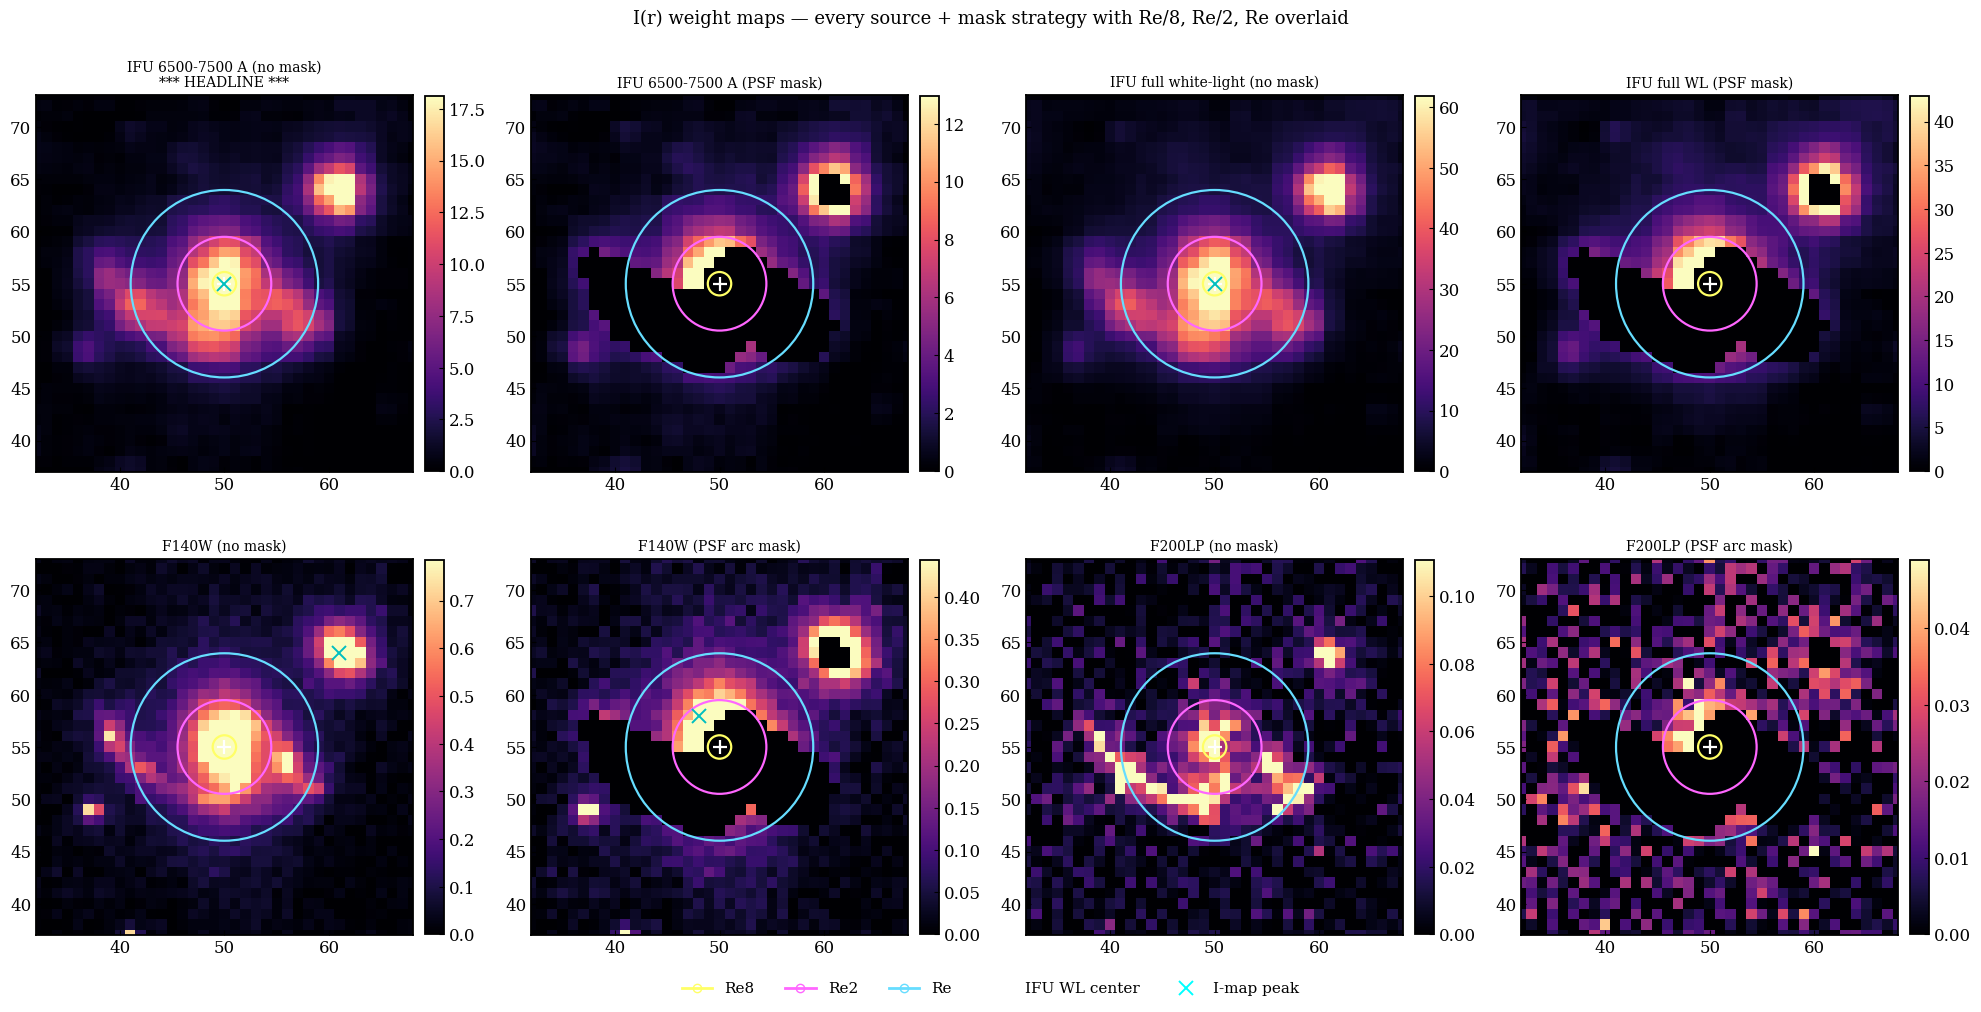

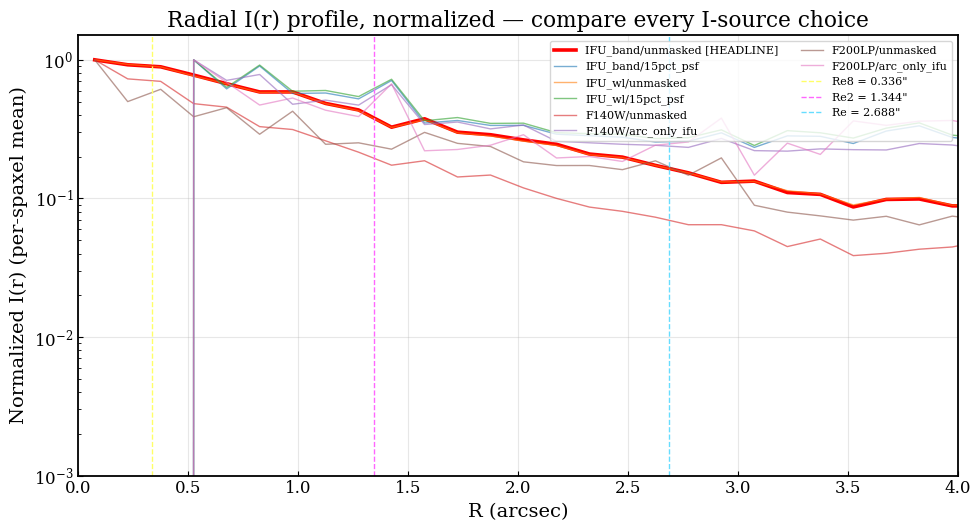


I_source   mask_strategy      peak (y,x)        sum   flux<Re/8   flux<Re/2    flux<Re
-----------------------------------------------------------------------------------------------
IFU_band  *unmasked      ( 55, 50)     4.855e+03   1.132e+02   9.711e+02  2.073e+03
IFU_band   15pct_psf     ( 31, 30)     2.879e+03   0.000e+00   2.228e+02  5.663e+02
IFU_wl     unmasked      ( 55, 50)     1.815e+04   3.967e+02   3.382e+03  7.186e+03
IFU_wl     15pct_psf     ( 31, 30)     1.137e+04   0.000e+00   7.884e+02  2.013e+03
F140W      unmasked      ( 64, 61)     2.742e+02   8.872e+00   5.428e+01  1.001e+02
F140W      arc_only_ifu  ( 58, 48)     1.752e+02   0.000e+00   1.097e+01  2.794e+01
F200LP     unmasked      ( 31, 30)     5.938e+01   6.538e-01   4.448e+00  1.119e+01
F200LP     arc_only_ifu  ( 31, 30)     4.644e+01   0.000e+00   8.459e-01  2.040e+00


In [23]:
# Side-by-side visualization of every I(r) candidate + mask strategy
# with Re/8, Re/2, Re aperture annuli overlaid.

from matplotlib.patches import Circle as _C

# Build all candidate I(r) maps (re-using build_I_weight_map)
viz_combos = [
    ('IFU_band', 'unmasked',     'IFU 6500-7500 A (no mask)\n*** HEADLINE ***'),
    ('IFU_band', '15pct_psf',    'IFU 6500-7500 A (PSF mask)'),
    ('IFU_wl',   'unmasked',     'IFU full white-light (no mask)'),
    ('IFU_wl',   '15pct_psf',    'IFU full WL (PSF mask)'),
    ('F140W',    'unmasked',     'F140W (no mask)'),
    ('F140W',    'arc_only_ifu', 'F140W (PSF arc mask)'),
    ('F200LP',   'unmasked',     'F200LP (no mask)'),
    ('F200LP',   'arc_only_ifu', 'F200LP (PSF arc mask)'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()
delta_z = 18
y1z, y2z = max(0, cy - delta_z), min(ny, cy + delta_z)
x1z, x2z = max(0, cx - delta_z), min(nx, cx + delta_z)

ap_colors = {'Re8': '#ffff66', 'Re2': '#ff66ff', 'Re': '#66ddff'}

# Compute pixel scale once
from astropy.wcs.utils import proj_plane_pixel_scales as _pixscales
pix_scale_local = float(np.abs(_pixscales(wcs_ifu_2d)[0])) * 3600.0

I_maps_for_profile = {}  # for the 1-D radial profile panel below

for ax, (src, msk, title) in zip(axes, viz_combos):
    try:
        I = build_I_weight_map(src, msk)
    except FileNotFoundError:
        ax.set_title(f'{title}\n(file not found)'); ax.axis('off'); continue
    I_maps_for_profile[(src, msk)] = I
    pos_I = I[I > 0]
    vmax = np.percentile(pos_I, 99) if len(pos_I) else 1.0
    im = ax.imshow(I, origin='lower', cmap='magma', vmin=0, vmax=vmax,
                   extent=[-0.5, nx-0.5, -0.5, ny-0.5])
    ax.set_xlim(x1z, x2z); ax.set_ylim(y1z, y2z)
    # apertures
    for tag, r_max in APERTURES.items():
        ax.add_patch(_C((cx, cy), r_max / pix_scale_local, fill=False,
                        edgecolor=ap_colors[tag], lw=1.6, label=tag))
    ax.plot(cx, cy, 'w+', ms=10, mew=1.6)
    # peak indicator
    from scipy.ndimage import gaussian_filter as _gf
    yp_I, xp_I = np.unravel_index(np.argmax(_gf(I, sigma=1.5)), I.shape)
    ax.plot(xp_I, yp_I, 'cx', ms=10, mew=1.4)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

# Single legend
handles_viz = [plt.Line2D([0],[0], marker='o', color=ap_colors[t], lw=2, mfc='none', label=t)
               for t in APERTURES] + [
    plt.Line2D([0],[0], marker='+', color='white', mew=2, ms=10, ls='', label='IFU WL center'),
    plt.Line2D([0],[0], marker='x', color='cyan', mew=1.4, ms=10, ls='', label='I-map peak'),
]
fig.legend(handles=handles_viz, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=11)

fig.suptitle('I(r) weight maps — every source + mask strategy with Re/8, Re/2, Re overlaid',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'sigma_e_Imaps_all_sources.png'), dpi=170, bbox_inches='tight')
plt.show()

# ── 1D radial I(r) profile, normalized ──
fig, ax = plt.subplots(figsize=(10, 5.5))
r_bins = np.arange(0.0, 5.0, 0.15)  # arcsec
r_mid = 0.5 * (r_bins[:-1] + r_bins[1:])

for (src, msk), I in I_maps_for_profile.items():
    is_headline = (src == 'IFU_band' and msk == 'unmasked')
    profile = np.zeros(len(r_mid))
    for i in range(len(r_mid)):
        ann = (r_spax >= r_bins[i]) & (r_spax < r_bins[i+1])
        profile[i] = I[ann].sum() / max(ann.sum(), 1)  # mean per spaxel in annulus
    if profile.max() > 0:
        profile = profile / profile.max()
    ax.plot(r_mid, profile,
            lw=(2.6 if is_headline else 1.0),
            color=('red' if is_headline else None),
            alpha=(1.0 if is_headline else 0.6),
            label=f'{src}/{msk}' + (' [HEADLINE]' if is_headline else ''))
for tag, r_max in APERTURES.items():
    ax.axvline(r_max, color=ap_colors[tag], ls='--', lw=1.0,
               label=f'{tag} = {r_max:.3f}"')
ax.set_xlabel('R (arcsec)'); ax.set_ylabel('Normalized I(r) (per-spaxel mean)')
ax.set_title('Radial I(r) profile, normalized — compare every I-source choice')
ax.set_xlim(0, 4); ax.set_yscale('log'); ax.set_ylim(1e-3, 1.5)
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'sigma_e_Iprofiles_all_sources.png'), dpi=170, bbox_inches='tight')
plt.show()

# ── Quantitative summary table ──
print(f'\n{"I_source":<10} {"mask_strategy":<14} {"peak (y,x)":>14} {"sum":>10} {"flux<Re/8":>11} {"flux<Re/2":>11} {"flux<Re":>10}')
print('-' * 95)
for (src, msk), I in I_maps_for_profile.items():
    is_h = '*' if (src=='IFU_band' and msk=='unmasked') else ' '
    from scipy.ndimage import gaussian_filter as _gf2
    yp_I, xp_I = np.unravel_index(np.argmax(_gf2(I, sigma=1.5)), I.shape)
    f_re8 = I[r_spax <= APERTURES['Re8']].sum()
    f_re2 = I[r_spax <= APERTURES['Re2']].sum()
    f_re  = I[r_spax <= APERTURES['Re']].sum()
    print(f'{src:<10}{is_h}{msk:<13} ({yp_I:>3d},{xp_I:>3d})    {I.sum():10.3e} {f_re8:11.3e} {f_re2:11.3e} {f_re:10.3e}')

In [24]:
# Load PowerBin V/sigma posteriors (already done in §3b cell 14, but re-load
# in case kernel state was lost or §3b not run yet).
_pb_path = os.path.join(RESULTS_DIR, 'test19_powerbin_results.npz')
_pb_data = np.load(_pb_path, allow_pickle=True)
pb_map = _pb_data['pb_map']
pbin_results = list(_pb_data['pbin_results'])
n_pbins = int(_pb_data['n_pbins'])
pb_y_slice, pb_x_slice = slice(35, 75), slice(30, 70)

# Re-project the PowerBin map onto the full IFU grid
pb_map_full = np.full((ny, nx), -1, dtype=int)
pb_map_full[pb_y_slice, pb_x_slice] = pb_map

# Build {bin_id: (V_p16, V_p50, V_p84, sig_p16, sig_p50, sig_p84, n_spax)}
pb_kin = {}
for r in pbin_results:
    pb_kin[int(r['bin_id'])] = (
        r['V_p16'], r['V_p50'], r['V_p84'],
        r['sig_p16'], r['sig_p50'], r['sig_p84'],
        r['n_spax'],
    )

# Per-spaxel radial distance was already computed in cell 5 -> r_spax (ny, nx)
# Identify spaxels where we have BOTH a PowerBin id AND a real radial distance.
print(f'Loaded {n_pbins} PowerBin bins from {_pb_path}')
print(f'PowerBin coverage: {(pb_map_full >= 0).sum()} of {ny*nx} IFU spaxels '
      f'({100*(pb_map_full>=0).sum()/(ny*nx):.1f}%)')

Loaded 19 PowerBin bins from ../results/test19_powerbin_results.npz
PowerBin coverage: 553 of 10000 IFU spaxels (5.5%)


In [25]:
def gultekin_sigma_e_pb(I_map, apertures, pb_map_full, pb_kin, r_spax,
                         n_mc, central_radius=0.6, seed=42,
                         max_sigma=500.0, max_abs_V=500.0,
                         max_sigma_frac_unc=0.5,
                         require_centroid_inside=True,
                         pbin_results=None):
    """
    Compute Gultekin/KH13 sigma_e for each aperture using PowerBin V,sigma posteriors
    and an I-weight map.

    For each Monte-Carlo draw k:
      1. For each PowerBin bin in scope, draw V_b, sigma_b from split-normal posteriors
      2. V_sys_k = median V_b for bins inside R<central_radius (split-normal redrawn)
      3. For each aperture: sigma_e^2 = sum(I_i * ((V_b[bin_i] - V_sys_k)^2 + sig_b[bin_i]^2)) / sum(I_i)
         where the sum is over spaxels i inside the aperture AND assigned to a PowerBin.

    Returns: dict tag -> dict(samples, p16, p50, p84, V_sys_samples, n_bins_used)
    """
    rng = np.random.default_rng(seed)

    # Quality filter: drop bins with unphysical sigma or bad fit
    # (these are typically outer bins where ppxf converged on a noise-driven
    # broad-blob fit; they would dominate the I-weighted sum if kept)
    # Quality filter — DROP a bin from the σ_e calculation if any of:
    #   (1) sig_p50 > max_sigma (unphysically broad — likely noise-driven blob)
    #   (2) abs(V_p50) > max_abs_V (way off systemic — also noise-driven)
    #   (3) (sig_p84 - sig_p16) / sig_p50 > max_sigma_frac_unc (poorly constrained)
    # NOTE: chi2 is NOT used as a cut — it correlates with bin radius (per-spaxel
    # noise normalization) rather than fit quality, so a chi2 cut would also drop
    # bins with reasonable σ at large R.
    bins_dropped = set()
    drop_reasons = {}
    if pbin_results is not None:
        for r in pbin_results:
            b = int(r['bin_id'])
            sig = r['sig_p50']; V = r['V_p50']
            sig_unc_frac = (r['sig_p84'] - r['sig_p16']) / max(sig, 1.0)
            reasons = []
            if sig > max_sigma:
                reasons.append(f'σ={sig:.0f}>{max_sigma:.0f}')
            if abs(V) > max_abs_V:
                reasons.append(f'|V|={abs(V):.0f}>{max_abs_V:.0f}')
            if sig_unc_frac > max_sigma_frac_unc:
                reasons.append(f'frac_unc={sig_unc_frac:.2f}>{max_sigma_frac_unc:.2f}')
            if reasons:
                bins_dropped.add(b)
                drop_reasons[b] = reasons
    bin_ids_used = sorted(int(b) for b in pb_kin.keys() if int(b) not in bins_dropped)

    # Bin centroid lookup (for centroid-inside filter)
    bin_centroids_r = {}  # bin_id -> mean radial distance of spaxels
    for b in pb_kin.keys():
        bi = int(b)
        m = (pb_map_full == bi)
        if m.sum() > 0:
            bin_centroids_r[bi] = float(r_spax[m].mean())

    if drop_reasons:
        print(f'  σ_e quality filter dropped {len(drop_reasons)} bins:')
        for b, reasons in sorted(drop_reasons.items()):
            print(f'    bin {b}: {", ".join(reasons)}')

    out = {}
    # Pre-compute per-aperture spaxel masks and bin lists
    per_aper = {}
    for tag, r_max in apertures.items():
        spax_mask = (r_spax <= r_max) & (pb_map_full >= 0)
        bin_ids_in = pb_map_full[spax_mask]
        I_in = I_map[spax_mask]
        # Apply BOTH filters: drop dropped bins AND drop bins whose centroid is outside
        keep_spax = np.ones(len(bin_ids_in), dtype=bool)
        for j, b in enumerate(bin_ids_in):
            bi = int(b)
            if bi not in pb_kin:
                keep_spax[j] = False  # bootstrap failed for this bin
            elif bi in bins_dropped:
                keep_spax[j] = False
            elif require_centroid_inside and bin_centroids_r.get(bi, 0) > r_max:
                keep_spax[j] = False
        bin_ids_in = bin_ids_in[keep_spax]
        I_in = I_in[keep_spax]
        per_aper[tag] = (spax_mask, bin_ids_in, I_in,
                         set(int(b) for b in np.unique(bin_ids_in)))

    # Identify "central" bins (R < central_radius) for V_sys.
    # Restrict to bins that survived the quality filter AND are in pb_kin.
    central_mask = (r_spax <= central_radius) & (pb_map_full >= 0)
    central_bins = sorted(set(int(b) for b in np.unique(pb_map_full[central_mask])
                              if int(b) in pb_kin and int(b) not in bins_dropped))
    if not central_bins:
        # fallback: use the closest unfiltered bin to the deflector center
        candidates = [(bin_centroids_r[bi], bi) for bi in bin_ids_used
                      if bi in bin_centroids_r]
        if candidates:
            central_bins = [sorted(candidates)[0][1]]

    sig_e_samples = {tag: np.full(n_mc, np.nan) for tag in apertures}
    V_sys_samples = np.full(n_mc, np.nan)

    for k in range(n_mc):
        # Draw V, sigma per bin
        Vb, Sb = {}, {}
        for b in bin_ids_used:
            Vp16, Vp50, Vp84, sp16, sp50, sp84, _ = pb_kin[int(b)]
            Vb[int(b)] = float(split_normal_draw(Vp16, Vp50, Vp84, rng))
            Sb[int(b)] = float(split_normal_draw(sp16, sp50, sp84, rng))
        V_sys = np.median([Vb[b] for b in central_bins]) if central_bins else 0.0
        V_sys_samples[k] = V_sys
        # σ_e per aperture
        for tag, (_, bin_ids_in, I_in, _) in per_aper.items():
            V_arr = np.array([Vb[int(b)] - V_sys for b in bin_ids_in])
            S_arr = np.array([Sb[int(b)] for b in bin_ids_in])
            num = float(np.sum(I_in * (V_arr**2 + S_arr**2)))
            denom = float(np.sum(I_in))
            sig_e_samples[tag][k] = np.sqrt(num / denom) if denom > 0 else np.nan

    for tag in apertures:
        s = sig_e_samples[tag]
        out[tag] = {
            'samples': s,
            'p16': float(np.nanpercentile(s, 16)),
            'p50': float(np.nanpercentile(s, 50)),
            'p84': float(np.nanpercentile(s, 84)),
            'n_bins_used': len(per_aper[tag][3]),
        }
    return out, V_sys_samples


# ── SMOKE TEST: N_MC=10, headline I=F140W proper-mask only ─────────
N_MC_SMOKE = 10
I_headline = build_I_weight_map('IFU_band', 'unmasked')
print(f'IFU 6500-7500 A band I map (HEADLINE): shape {I_headline.shape}, '
      f'sum {I_headline.sum():.3e}, peak at '
      f'{np.unravel_index(np.argmax(I_headline), I_headline.shape)}')

sig_e_smoke, V_sys_smoke = gultekin_sigma_e_pb(
    I_headline, APERTURES, pb_map_full, pb_kin, r_spax,
    n_mc=N_MC_SMOKE, central_radius=0.6, seed=42,
    max_sigma=500.0, max_abs_V=500.0, max_sigma_frac_unc=0.5,
    require_centroid_inside=True,
    pbin_results=pbin_results,
)

print(f'\n=== σ_e smoke test (N_MC={N_MC_SMOKE}, I=IFU 6500-7500 A band, kin=EMILES PowerBin) ===')
print(f'V_sys draws (km/s): median={np.median(V_sys_smoke):+.0f}, '
      f'spread {np.std(V_sys_smoke):.1f}')
print()
print(f'{"aperture":<8} {"R (arcsec)":>11} {"N_bins":>8} {"sigma_e (median)":>18} {"-err":>6} {"+err":>6}')
print('-' * 72)
for tag in APERTURES:
    s = sig_e_smoke[tag]
    sa_p50 = combined[tag]['p50']  # spatially-averaged from §7 for comparison
    delta = s['p50'] - sa_p50
    print(f'{tag:<8} {APERTURES[tag]:11.3f} {s["n_bins_used"]:8d} '
          f'{s["p50"]:18.0f} {s["p50"]-s["p16"]:6.0f} {s["p84"]-s["p50"]:6.0f}  '
          f'(spatially-averaged={sa_p50:.0f}, Δ={delta:+.0f})')

print(f'\nSanity: σ_e(<Re/8) > spatially-averaged σ(<Re/8)? '
      f'{sig_e_smoke["Re8"]["p50"] > combined["Re8"]["p50"]}')

IFU 6500-7500 A band I map (HEADLINE): shape (100, 100), sum 4.855e+03, peak at (np.int64(31), np.int64(30))
  σ_e quality filter dropped 12 bins:
    bin 1: frac_unc=0.62>0.50
    bin 2: frac_unc=0.61>0.50
    bin 5: frac_unc=0.83>0.50
    bin 6: σ=746>500
    bin 7: frac_unc=0.75>0.50
    bin 8: frac_unc=0.76>0.50
    bin 9: σ=869>500, |V|=928>500
    bin 11: σ=822>500
    bin 12: frac_unc=0.52>0.50
    bin 13: frac_unc=1.50>0.50
    bin 16: frac_unc=0.97>0.50
    bin 17: frac_unc=3.17>0.50

=== σ_e smoke test (N_MC=10, I=IFU 6500-7500 A band, kin=EMILES PowerBin) ===
V_sys draws (km/s): median=+98, spread 12.1

aperture  R (arcsec)   N_bins   sigma_e (median)   -err   +err
------------------------------------------------------------------------
Re8            0.336        1                282     18     27  (spatially-averaged=216, Δ=+66)
Re2            1.344        4                246      9     16  (spatially-averaged=237, Δ=+9)
Re             2.688        5                310   

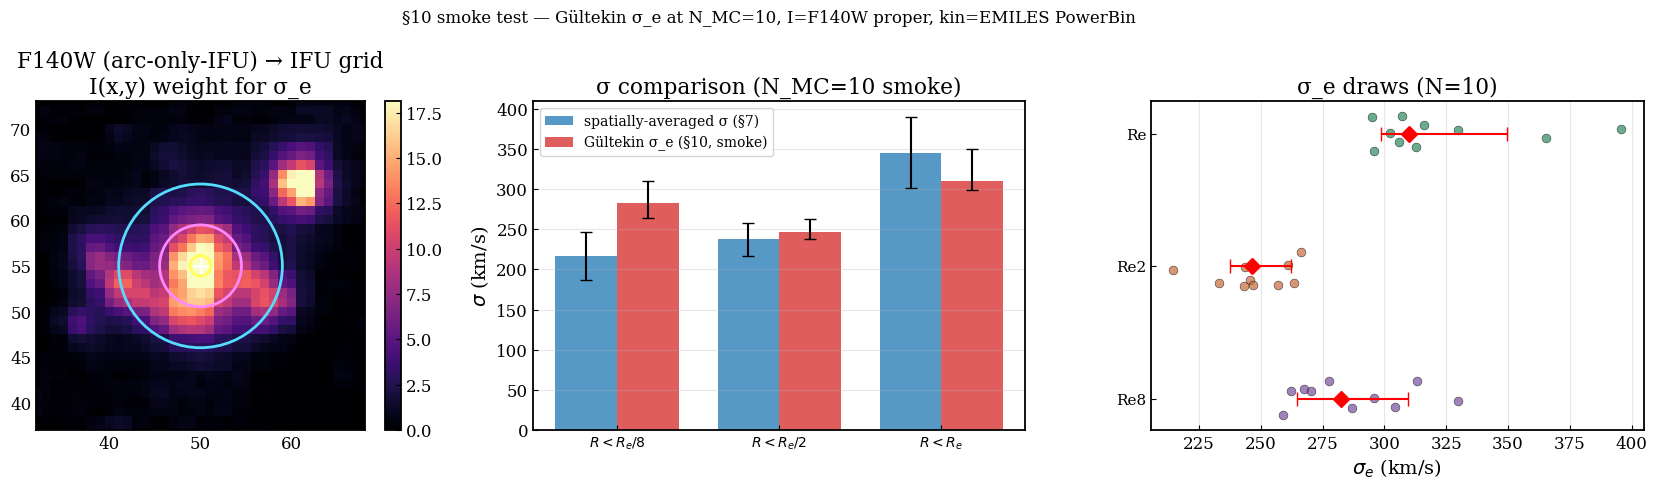

In [26]:
# Smoke-test visualization: F140W I map + apertures + bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: F140W proper-mask I map with apertures overlaid
from matplotlib.patches import Circle as _Circle
delta_z = 18
y1z, y2z = max(0, cy - delta_z), min(ny, cy + delta_z)
x1z, x2z = max(0, cx - delta_z), min(nx, cx + delta_z)
ax = axes[0]
im0 = ax.imshow(I_headline, origin='lower', cmap='magma',
                extent=[-0.5, nx-0.5, -0.5, ny-0.5],
                vmin=0, vmax=np.percentile(I_headline[I_headline>0], 99))
ax.set_xlim(x1z, x2z); ax.set_ylim(y1z, y2z)
for tag, r_max in APERTURES.items():
    ax.add_patch(_Circle((cx, cy), r_max / pix_scale, fill=False,
                         edgecolor={'Re8':'#ffff55','Re2':'#ff88ff','Re':'#55ddff'}[tag],
                         lw=2.0, label=tag))
ax.plot(cx, cy, 'w+', ms=12, mew=2)
ax.set_title('F140W (arc-only-IFU) → IFU grid\nI(x,y) weight for σ_e')
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

# Panel 2: bar chart comparing spatially-averaged σ vs Gültekin σ_e
ax = axes[1]
xpos = np.arange(len(APERTURES))
sa_vals = [combined[tag]['p50'] for tag in APERTURES]
sa_lo = [combined[tag]['p50'] - combined[tag]['p16'] for tag in APERTURES]
sa_hi = [combined[tag]['p84'] - combined[tag]['p50'] for tag in APERTURES]
se_vals = [sig_e_smoke[tag]['p50'] for tag in APERTURES]
se_lo = [sig_e_smoke[tag]['p50'] - sig_e_smoke[tag]['p16'] for tag in APERTURES]
se_hi = [sig_e_smoke[tag]['p84'] - sig_e_smoke[tag]['p50'] for tag in APERTURES]
w = 0.38
ax.bar(xpos - w/2, sa_vals, w, yerr=[sa_lo, sa_hi], capsize=4,
       color='C0', alpha=0.75, label='spatially-averaged σ (§7)')
ax.bar(xpos + w/2, se_vals, w, yerr=[se_lo, se_hi], capsize=4,
       color='C3', alpha=0.75, label='Gültekin σ_e (§10, smoke)')
ax.set_xticks(xpos)
ax.set_xticklabels([APERTURE_LABELS[t].split('(')[0].strip() for t in APERTURES], fontsize=10)
ax.set_ylabel(r'$\sigma$ (km/s)')
ax.set_title(f'σ comparison (N_MC={N_MC_SMOKE} smoke)')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

# Panel 3: posterior strip plot at N_MC=10 (too few for histogram)
ax = axes[2]
hist_colors = {'Re8': '#7a4fa0', 'Re2': '#c86a3e', 'Re': '#2a8a5e'}
for j, tag in enumerate(APERTURES):
    s = sig_e_smoke[tag]['samples']
    s = s[np.isfinite(s)]
    ax.scatter(s, np.full_like(s, j) + np.random.uniform(-0.15, 0.15, len(s)),
               color=hist_colors[tag], alpha=0.7, s=40, edgecolor='black', lw=0.4)
    ax.errorbar([sig_e_smoke[tag]['p50']], [j], xerr=[[sig_e_smoke[tag]['p50']-sig_e_smoke[tag]['p16']],
                                                      [sig_e_smoke[tag]['p84']-sig_e_smoke[tag]['p50']]],
                fmt='D', color='red', capsize=5, markersize=8, zorder=10)
ax.set_yticks(range(len(APERTURES)))
ax.set_yticklabels(list(APERTURES.keys()), fontsize=11)
ax.set_xlabel(r'$\sigma_e$ (km/s)')
ax.set_title(f'σ_e draws (N={N_MC_SMOKE})')
ax.grid(alpha=0.3, axis='x')

fig.suptitle(f'§10 smoke test — Gültekin σ_e at N_MC={N_MC_SMOKE}, I=F140W proper, kin=EMILES PowerBin',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'sigma_e_smoke.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11. Full run — N_MC=500, per-SPS shell-averaged, multi-I-source comparison

Production version of §10. Adds:

1. **N_MC = 500** (from 10).
2. **Per-SPS shell-averaged σ_e (§11c).** Uses the per-aperture per-SPS bootstrap arrays already saved by §5 (`results/ppxf_bootstrap_errors_R_le_*_*_z067564.npz`). For each SPS lib (FSPS, EMILES, XSL) we compute a shell-averaged σ_e using the spatially-averaged V, σ at three radial shells (Re/8, Re/8-Re/2, Re/2-Re), each weighted by the F140W flux integrated over that shell. Per-SPS V_sys offsets ("split track") are subtracted before squaring V.
3. **I(r) systematic comparison (§11g).** Re-runs the PowerBin Gültekin σ_e for all 8 (I_source, mask_strategy) combinations from §10b. Quantifies how much σ_e depends on the I-weighting choice.

In [ ]:
# §11b: PowerBin Gültekin σ_e at full N_MC
N_MC_FULL = 500
sig_e_pb, V_sys_pb = gultekin_sigma_e_pb(
    I_headline, APERTURES, pb_map_full, pb_kin, r_spax,
    n_mc=N_MC_FULL, central_radius=0.6, seed=42,
    max_sigma=500.0, max_abs_V=500.0, max_sigma_frac_unc=0.5,
    require_centroid_inside=True,
    pbin_results=pbin_results,
)
print(f'=== §11b: PowerBin Gültekin σ_e (HEADLINE, N_MC={N_MC_FULL}) ===')
print(f'V_sys: median={np.median(V_sys_pb):+.0f}, std={np.std(V_sys_pb):.1f} km/s')
print()
for tag in APERTURES:
    s = sig_e_pb[tag]
    print(f'  σ_e(<{tag})  = {s["p50"]:.0f}  -{s["p50"]-s["p16"]:.0f}/+{s["p84"]-s["p50"]:.0f} km/s '
          f'   [{s["n_bins_used"]} bins inside aperture]')

In [ ]:
# §11c: per-SPS shell-averaged σ_e from §5 aperture-bootstrap data
# Loads the per-aperture per-SPS bootstrap arrays saved by §5.

def shell_flux_I(r_lo, r_hi, I_map=I_headline, r_spax=r_spax):
    """Sum F140W intensity over spaxels with r_lo <= r < r_hi."""
    m = (r_spax >= r_lo) & (r_spax < r_hi)
    return float(I_map[m].sum())

# Define shells consistent with the apertures
SHELL_EDGES = [0.0, APERTURES['Re8'], APERTURES['Re2'], APERTURES['Re']]
SHELL_TAGS = ['Re8', 'Re2', 'Re']  # the upper edge of each shell -> aperture name
F_shells = np.array([shell_flux_I(SHELL_EDGES[j], SHELL_EDGES[j+1])
                     for j in range(3)])
print(f'IFU-band shell fluxes: {F_shells}  (Re/8 / Re8-Re2 / Re2-Re)')
F_apertures = {'Re8': F_shells[0],
               'Re2': F_shells[0] + F_shells[1],
               'Re':  F_shells.sum()}

# Load per-aperture per-SPS bootstrap arrays
shell_boot = {}  # (tag, sps) -> dict
missing = []
for tag in APERTURES:
    for sps in SPS_LIBS:
        p = os.path.join(RESULTS_DIR, f'ppxf_bootstrap_errors_R_le_{tag}_{sps}_z067564.npz')
        if not os.path.exists(p):
            missing.append(p); continue
        shell_boot[(tag, sps)] = dict(np.load(p, allow_pickle=True))

if missing:
    print('** WARNING: missing per-aperture bootstrap files (§5 not yet run at full N=500):')
    for p in missing:
        print(f'   {p}')
    print('   §11c will use whatever is available.')

# Per-SPS V_offset from the central aperture (Re/8) median V across COMBINE_DEG_RANGE
V_offset_per_sps = {}
for sps in SPS_LIBS:
    key = ('Re8', sps)
    if key not in shell_boot:
        V_offset_per_sps[sps] = 0.0; continue
    b = shell_boot[key]
    deg_mask = np.isin(b['degrees'], COMBINE_DEG_RANGE)
    V_offset_per_sps[sps] = float(np.nanmedian(b['V_p50'][deg_mask]))
print(f'\nPer-SPS V_offset (median V_p50 at Re/8, deg in COMBINE_DEG_RANGE):')
for sps, v in V_offset_per_sps.items():
    print(f'  {sps:8s} : {v:+.1f} km/s')

def sample_split_normal_array(p16, p50, p84, n_samples, rng):
    """Vectorized split-normal: input arrays of shape (n,), output (n_samples, n)."""
    sig_lo = np.maximum(p50 - p16, 1e-3)
    sig_hi = np.maximum(p84 - p50, 1e-3)
    side = rng.random((n_samples, len(p50))) < 0.5
    z = np.abs(rng.standard_normal((n_samples, len(p50))))
    return np.where(side, p50 - z * sig_lo, p50 + z * sig_hi)

# Compute per-SPS shell-averaged σ_e
rng = np.random.default_rng(123)
sig_e_shell = {}
for sps in SPS_LIBS:
    if not all((t, sps) in shell_boot for t in SHELL_TAGS):
        print(f'Skipping {sps} (missing aperture data)')
        continue
    samples_list = []
    for d_eff in COMBINE_DEG_RANGE:
        # Per shell, use this SPS's V_p50/sig_p50 at degree d_eff
        # Build arrays of (V_p16, V_p50, V_p84) and (sig_p16, sig_p50, sig_p84) over shells
        Vp16, Vp50, Vp84, sp16, sp50, sp84 = [], [], [], [], [], []
        ok = True
        for t in SHELL_TAGS:
            b = shell_boot[(t, sps)]
            try:
                idx = int(np.where(b['degrees'] == d_eff)[0][0])
            except IndexError:
                ok = False; break
            Vp16.append(b['V_p16'][idx]); Vp50.append(b['V_p50'][idx]); Vp84.append(b['V_p84'][idx])
            sp16.append(b['sigma_p16'][idx]); sp50.append(b['sigma_p50'][idx]); sp84.append(b['sigma_p84'][idx])
        if not ok: continue
        Vp16 = np.array(Vp16); Vp50 = np.array(Vp50); Vp84 = np.array(Vp84)
        sp16 = np.array(sp16); sp50 = np.array(sp50); sp84 = np.array(sp84)
        n_per_deg = N_MC_FULL
        V_draws = sample_split_normal_array(Vp16, Vp50, Vp84, n_per_deg, rng) - V_offset_per_sps[sps]
        S_draws = sample_split_normal_array(sp16, sp50, sp84, n_per_deg, rng)
        # Compute σ_e per aperture
        for tag, F_total in F_apertures.items():
            n_shells = SHELL_TAGS.index(tag) + 1
            num = (F_shells[:n_shells] * (V_draws[:, :n_shells]**2 + S_draws[:, :n_shells]**2)).sum(axis=1)
            denom = F_shells[:n_shells].sum()
            sig_e_arr = np.sqrt(num / denom)
            sig_e_shell.setdefault((sps, tag), []).extend(sig_e_arr.tolist())

# Aggregate per (SPS, tag)
sig_e_shell_summary = {}
for (sps, tag), s in sig_e_shell.items():
    s = np.array(s)
    sig_e_shell_summary[(sps, tag)] = {
        'samples': s,
        'p16': float(np.nanpercentile(s, 16)),
        'p50': float(np.nanpercentile(s, 50)),
        'p84': float(np.nanpercentile(s, 84)),
    }

print(f'\n=== §11c: per-SPS shell-averaged σ_e (3 shells, IFU-band I-weighted, per-SPS V offset) ===')
print(f'{"SPS":<8} {"aperture":<8} {"sigma_e":>9} {"-err":>6} {"+err":>6}  N_samples')
for sps in SPS_LIBS:
    for tag in APERTURES:
        if (sps, tag) not in sig_e_shell_summary: continue
        s = sig_e_shell_summary[(sps, tag)]
        print(f'{sps:<8} {tag:<8} {s["p50"]:9.0f} {s["p50"]-s["p16"]:6.0f} {s["p84"]-s["p50"]:6.0f}    {len(s["samples"])}')

# Combined-SPS shell σ_e (concatenate samples across SPS)
sig_e_shell_combined = {}
for tag in APERTURES:
    pooled = np.concatenate([sig_e_shell_summary[(sps, tag)]['samples']
                             for sps in SPS_LIBS if (sps, tag) in sig_e_shell_summary])
    if len(pooled) == 0: continue
    sig_e_shell_combined[tag] = {
        'samples': pooled,
        'p16': float(np.nanpercentile(pooled, 16)),
        'p50': float(np.nanpercentile(pooled, 50)),
        'p84': float(np.nanpercentile(pooled, 84)),
    }

print(f'\nCombined-SPS shell σ_e (FSPS + EMILES + XSL pooled):')
for tag, s in sig_e_shell_combined.items():
    print(f'  σ_e(<{tag}) = {s["p50"]:.0f}  -{s["p50"]-s["p16"]:.0f}/+{s["p84"]-s["p50"]:.0f} km/s')

In [ ]:
# §11g: I(r) systematic comparison
# Re-run the PowerBin Gültekin σ_e for every (I_source, mask_strategy) combo.
I_source_combos = [
    ('IFU_band','unmasked'), ('IFU_band','15pct_psf'),  # HEADLINE family
    ('IFU_wl',  'unmasked'), ('IFU_wl',  '15pct_psf'),
    ('F140W',   'unmasked'), ('F140W',   'arc_only_ifu'),
    ('F200LP',  'unmasked'), ('F200LP',  'arc_only_ifu'),
]
N_MC_ISRC = max(N_MC_FULL // 2, 100)  # half N_MC each to keep total runtime reasonable

print(f'=== §11g: σ_e vs I(r) source (N_MC={N_MC_ISRC} per combo) ===')
print(f'{"I_source":<10} {"mask":<12} ' +
      ' '.join([f'{("σ_e(<"+t+")"):>16}' for t in APERTURES]))
print('-' * 80)

isource_table = []
for src, msk in I_source_combos:
    try:
        I_map = build_I_weight_map(src, msk)
    except FileNotFoundError as e:
        print(f'{src:<10} {msk:<12} skipped (file not found)')
        continue
    se_dict, _ = gultekin_sigma_e_pb(I_map, APERTURES, pb_map_full, pb_kin, r_spax,
                                     n_mc=N_MC_ISRC, central_radius=0.6, seed=42,
                                     max_sigma=500.0, max_abs_V=500.0,
                                     max_sigma_frac_unc=0.5,
                                     require_centroid_inside=True,
                                     pbin_results=pbin_results)
    row = {'I_source': src, 'mask_strategy': msk}
    line = f'{src:<10} {msk:<12} '
    for tag in APERTURES:
        s = se_dict[tag]
        line += f'{s["p50"]:5.0f} -{s["p50"]-s["p16"]:.0f}/+{s["p84"]-s["p50"]:.0f}'.rjust(17)
        row[f'{tag}_p16'] = s['p16']; row[f'{tag}_p50'] = s['p50']; row[f'{tag}_p84'] = s['p84']
    print(line)
    isource_table.append(row)

# Bar chart: σ_e(<Re) for each I-source combo
fig, ax = plt.subplots(figsize=(9, 5))
labels_isrc = [f'{r["I_source"]}/{r["mask_strategy"]}' for r in isource_table]
vals = [r['Re_p50'] for r in isource_table]
errs_lo = [r['Re_p50'] - r['Re_p16'] for r in isource_table]
errs_hi = [r['Re_p84'] - r['Re_p50'] for r in isource_table]
colors_b = ['C2' if (r['I_source']=='IFU_band' and r['mask_strategy']=='unmasked') else 'C0'
            for r in isource_table]
bars = ax.bar(range(len(labels_isrc)), vals, yerr=[errs_lo, errs_hi], capsize=4,
              color=colors_b, alpha=0.8, edgecolor='black', lw=0.5)
# Highlight headline F140W-proper bar
for bar, r in zip(bars, isource_table):
    if r['I_source']=='IFU_band' and r['mask_strategy']=='unmasked':
        bar.set_edgecolor('red'); bar.set_linewidth(2.2)
ax.set_xticks(range(len(labels_isrc))); ax.set_xticklabels(labels_isrc, rotation=35, ha='right')
ax.set_ylabel(r'$\sigma_e(<R_e)$ (km/s)')
ax.set_title(f'σ_e(<R_e) vs I(r) choice (red = headline IFU 6500-7500 A unmasked)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'sigma_e_isource_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# Spread analysis
sigma_e_Re_vals = [r['Re_p50'] for r in isource_table]
print(f'\nσ_e(<Re) spread across I-sources: '
      f'min {min(sigma_e_Re_vals):.0f}, max {max(sigma_e_Re_vals):.0f}, '
      f'spread {max(sigma_e_Re_vals)-min(sigma_e_Re_vals):.0f} km/s '
      f'({100*(max(sigma_e_Re_vals)-min(sigma_e_Re_vals))/np.mean(sigma_e_Re_vals):.0f}%)')

In [ ]:
# §11e: three-panel headline comparison plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Panel 1: σ_e at three apertures, three rows (PB, per-SPS shell, combined-SPS shell)
ax = axes[0]
y_offset = {'pb': 0.30, 'fsps': 0.0, 'emiles': -0.10, 'xsl': -0.20, 'combined': -0.40}
y_label = {'pb': 'PowerBin (EMILES)', 'fsps': 'FSPS shell',
           'emiles': 'EMILES shell', 'xsl': 'XSL shell', 'combined': 'Combined shell'}
y_color = {'pb': 'C3', 'fsps': 'C0', 'emiles': 'C1', 'xsl': 'C2', 'combined': 'black'}
for j, tag in enumerate(APERTURES):
    # PowerBin
    s = sig_e_pb[tag]
    ax.errorbar(s['p50'], j + y_offset['pb'],
                xerr=[[s['p50']-s['p16']], [s['p84']-s['p50']]],
                fmt='D', color=y_color['pb'], markersize=10, capsize=4, lw=1.5,
                label=(y_label['pb'] if j==0 else None))
    # Per-SPS
    for sps in SPS_LIBS:
        if (sps, tag) not in sig_e_shell_summary: continue
        s2 = sig_e_shell_summary[(sps, tag)]
        ax.errorbar(s2['p50'], j + y_offset[sps],
                    xerr=[[s2['p50']-s2['p16']], [s2['p84']-s2['p50']]],
                    fmt='o', color=y_color[sps], markersize=7, capsize=3,
                    label=(y_label[sps] if j==0 else None))
    # Combined
    if tag in sig_e_shell_combined:
        s3 = sig_e_shell_combined[tag]
        ax.errorbar(s3['p50'], j + y_offset['combined'],
                    xerr=[[s3['p50']-s3['p16']], [s3['p84']-s3['p50']]],
                    fmt='s', color=y_color['combined'], markersize=8, capsize=4, lw=1.5,
                    label=(y_label['combined'] if j==0 else None))

ax.set_yticks(range(len(APERTURES)))
ax.set_yticklabels(['Re/8', 'Re/2', 'Re'], fontsize=12)
ax.set_xlabel(r'$\sigma_e$ (km/s)')
ax.set_title('Gültekin σ_e by method')
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3, axis='x')

# Panel 2: spatially-averaged σ from §7 vs Gültekin σ_e PowerBin
ax = axes[1]
xpos = np.arange(len(APERTURES))
sa_p50 = [combined[t]['p50'] for t in APERTURES]
sa_lo = [combined[t]['p50']-combined[t]['p16'] for t in APERTURES]
sa_hi = [combined[t]['p84']-combined[t]['p50'] for t in APERTURES]
se_p50 = [sig_e_pb[t]['p50'] for t in APERTURES]
se_lo = [sig_e_pb[t]['p50']-sig_e_pb[t]['p16'] for t in APERTURES]
se_hi = [sig_e_pb[t]['p84']-sig_e_pb[t]['p50'] for t in APERTURES]
w = 0.38
ax.bar(xpos-w/2, sa_p50, w, yerr=[sa_lo, sa_hi], capsize=4, color='C0', alpha=0.75,
       label='spatially-averaged σ (§7)')
ax.bar(xpos+w/2, se_p50, w, yerr=[se_lo, se_hi], capsize=4, color='C3', alpha=0.75,
       label='Gültekin σ_e (PowerBin, F140W)')
ax.set_xticks(xpos); ax.set_xticklabels(['Re/8', 'Re/2', 'Re'])
ax.set_ylabel(r'$\sigma$ (km/s)')
ax.set_title('Gültekin σ_e vs spatially-averaged σ')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

# Panel 3: posterior histograms for σ_e(<Re) from each method
ax = axes[2]
ax.hist(sig_e_pb['Re']['samples'], bins=40, alpha=0.5, label='PowerBin (EMILES)',
        color=y_color['pb'], density=True)
for sps in SPS_LIBS:
    if (sps, 'Re') in sig_e_shell_summary:
        ax.hist(sig_e_shell_summary[(sps, 'Re')]['samples'], bins=40, alpha=0.45,
                label=f'{sps} shell', color=y_color[sps], density=True)
if 'Re' in sig_e_shell_combined:
    ax.hist(sig_e_shell_combined['Re']['samples'], bins=40, alpha=0.4,
            label='Combined shell', color=y_color['combined'], density=True,
            histtype='step', lw=2.0)
ax.set_xlabel(r'$\sigma_e(<R_e)$ (km/s)')
ax.set_ylabel('Density')
ax.set_title('σ_e(<Re) posterior by method')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

fig.suptitle(f'§11 — σ_e for AGEL0206 (M•-σ definition; F140W-proper headline, '
             f'N_MC={N_MC_FULL})', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'sigma_e_full_headline.png'), dpi=180, bbox_inches='tight')
plt.show()

In [ ]:
# §11d: save extended results
# Build the final extended npz, preserving the existing keys from §8
existing = dict(np.load(os.path.join(RESULTS_DIR, 'final_sigma_Re_apertures.npz'),
                        allow_pickle=True))
# Drop existing sigma_e_* keys so we can overwrite cleanly
for k in list(existing.keys()):
    if k.startswith('sigma_e_'):
        existing.pop(k)

# Add Gültekin σ_e fields
for tag in APERTURES:
    existing[f'sigma_e_pb_samples_{tag}'] = sig_e_pb[tag]['samples']
    existing[f'sigma_e_pb_{tag}_p16'] = sig_e_pb[tag]['p16']
    existing[f'sigma_e_pb_{tag}_p50'] = sig_e_pb[tag]['p50']
    existing[f'sigma_e_pb_{tag}_p84'] = sig_e_pb[tag]['p84']

for sps in SPS_LIBS:
    for tag in APERTURES:
        if (sps, tag) not in sig_e_shell_summary: continue
        s = sig_e_shell_summary[(sps, tag)]
        existing[f'sigma_e_shell_samples_{sps}_{tag}'] = s['samples']
        existing[f'sigma_e_shell_{sps}_{tag}_p16'] = s['p16']
        existing[f'sigma_e_shell_{sps}_{tag}_p50'] = s['p50']
        existing[f'sigma_e_shell_{sps}_{tag}_p84'] = s['p84']

for tag, s in sig_e_shell_combined.items():
    existing[f'sigma_e_shell_combined_{tag}_p16'] = s['p16']
    existing[f'sigma_e_shell_combined_{tag}_p50'] = s['p50']
    existing[f'sigma_e_shell_combined_{tag}_p84'] = s['p84']
    existing[f'sigma_e_shell_combined_samples_{tag}'] = s['samples']

for sps, v in V_offset_per_sps.items():
    existing[f'V_offset_{sps}'] = v

# I(r) systematic table
existing['sigma_e_pb_Isource_table'] = np.array(isource_table, dtype=object)

# Provenance
existing['sigma_e_method'] = 'Gultekin2009_eq1_KH13'
existing['sigma_e_I_source'] = 'IFU_6500_7500A_band'
existing['sigma_e_kin_source_pb'] = 'PowerBin_test19_EMILES'
existing['sigma_e_kin_source_shell'] = 'aperture_bootstrap_FSPS_EMILES_XSL'
existing['sigma_e_n_mc'] = N_MC_FULL

out_path = os.path.join(RESULTS_DIR, 'final_sigma_Re_apertures.npz')
np.savez(out_path, **existing)
print(f'Saved (with σ_e additions): {out_path}')

# ── HEADLINE PRINT ──
print()
print('=' * 70)
print('=== σ_e for the M•-σ relation (Gültekin 2009 / KH13 / Greene+20) ===')
print('=' * 70)
print(f'\nHEADLINE — PowerBin Gültekin, I=IFU 6500-7500 A band, kin=EMILES PowerBin:')
for tag in APERTURES:
    s = sig_e_pb[tag]
    note = '   *** primary number for ApJL Figure 3 ***' if tag == 'Re' else ('   [JFK95 legacy]' if tag == 'Re8' else '')
    print(f'  σ_e(<{tag}) = {s["p50"]:.0f}  -{s["p50"]-s["p16"]:.0f}/+{s["p84"]-s["p50"]:.0f} km/s{note}')

print(f'\nPer-SPS shell-averaged (3 radial shells, IFU-band I-weight, per-SPS V offset):')
for sps in SPS_LIBS:
    if (sps, 'Re') in sig_e_shell_summary:
        s = sig_e_shell_summary[(sps, 'Re')]
        print(f'  {sps:<7s}: σ_e(<Re) = {s["p50"]:.0f}  -{s["p50"]-s["p16"]:.0f}/+{s["p84"]-s["p50"]:.0f} km/s   '
              f'(V_offset = {V_offset_per_sps[sps]:+.0f} km/s)')
if 'Re' in sig_e_shell_combined:
    s = sig_e_shell_combined['Re']
    print(f'  Combined: σ_e(<Re) = {s["p50"]:.0f}  -{s["p50"]-s["p16"]:.0f}/+{s["p84"]-s["p50"]:.0f} km/s')